# Returns to a College Degree on Income — Adult Census Income (Double ML)

**Dataset:** [UCI Adult / "Census Income"](https://archive.ics.uci.edu/dataset/2/adult) — 48,842 individuals from the 1994 US Census.

**Research question:** does holding a college degree *causally* raise the probability of earning more than \$50K/year, once we adjust for the demographic and labour-market factors that jointly drive both who gets a degree and who earns well?

| Role | Variable | Definition |
|---|---|---|
| Treatment $D$ | `college_degree` | `education-num >= 13` (Bachelors, Masters, Prof-school, Doctorate) — binary 0/1 |
| Outcome $Y$ | `income_gt50k` | `income == '>50K'` — binary 0/1 |
| Confounders $X$ | all remaining features | age, workclass, `fnlwgt`, marital-status, occupation, relationship, race, sex, capital-gain, capital-loss, hours-per-week, native-country |
| Estimand | **ATT** | Average Treatment Effect on the **Treated** — the effect of a degree, *for the people who actually hold one* |

**Why DML and why ATT.** Degree attainment is not random: it is driven by an intersecting, nonlinear combination of family background, occupation, hours worked and capital income. A plain linear/logistic adjustment misses exactly the threshold and interaction effects census data is full of. `DoubleMLIRM` with `score='ATTE'` plugs flexible ML learners into both the outcome regression $g(X)$ and the propensity score $m(X)$ while still returning a valid, debiased ATT.

**Identification note (bad-control exclusion).** `education` and `education-num` are excluded from $X$: `education-num` *defines* $D$ by construction, so conditioning on it would be circular.

In [2]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import doubleml as dml
from ucimlrepo import fetch_ucirepo

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import (cross_val_score, KFold,
                                     StratifiedKFold, cross_val_predict)
from xgboost import XGBClassifier
import optuna

import statsmodels.api as sm
from scipy import stats

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

%matplotlib inline
sns.set_theme(style='whitegrid', font_scale=1.05)
COL = sns.color_palette()
optuna.logging.set_verbosity(optuna.logging.WARNING)
RNG = 42

## 1. Load & Prepare Data

`fetch_ucirepo(id=2)` pulls the Adult data and merges the historical train/test splits into one 48,842-row table (DML does its own cross-fitting, so no held-out split is needed).

**Cleaning:** missing `workclass` / `occupation` / `native-country` (encoded as `'?'` or, after the string cast, `'nan'`) are recoded to a single explicit `'Unknown'` category rather than dropped. `native-country` (42 levels, ~90% `United-States`) is collapsed to the top-9 countries + `'Other'`.

In [3]:
ds = fetch_ucirepo(id=2)
df = pd.concat([ds.data.features, ds.data.targets], axis=1)
df.columns = df.columns.str.strip()

# UCI ships string columns with stray spaces; adult.test rows have a trailing '.'
# on the income label ('>50K.' vs '>50K'). Normalise both.
for c in df.select_dtypes(include='object').columns:
    df[c] = df[c].astype(str).str.strip()

print(f"Loaded: {df.shape[0]:,} rows x {df.shape[1]} columns")

Loaded: 48,842 rows x 15 columns


In [4]:
# Missing-value recoding: '?' and stringified true-NaN -> single 'Unknown' category
for c in ['workclass', 'occupation', 'native-country']:
    df[c] = df[c].replace(['?', 'nan'], 'Unknown')

# Collapse high-cardinality native-country to top-9 + 'Other'
top_countries = df['native-country'].value_counts().nlargest(9).index.tolist()
df['native_country_grp'] = np.where(
    df['native-country'].isin(top_countries), df['native-country'], 'Other')

# Treatment and outcome
df['college_degree'] = (df['education-num'] >= 13).astype(int)
df['income_gt50k']   = df['income'].str.rstrip('.').eq('>50K').astype(int)

Y, D = 'income_gt50k', 'college_degree'
CONTINUOUS  = ['age', 'fnlwgt', 'capital-gain', 'capital-loss', 'hours-per-week']
CATEGORICAL = ['workclass', 'marital-status', 'occupation', 'relationship',
               'race', 'sex', 'native_country_grp']
# education / education-num excluded: they define D (bad control)

print(f"D = {D:<15} prevalence: {df[D].mean():.4f}")
print(f"Y = {Y:<15} prevalence: {df[Y].mean():.4f}")

D = college_degree  prevalence: 0.2479
Y = income_gt50k    prevalence: 0.2393


## 2. Exploratory Data Analysis

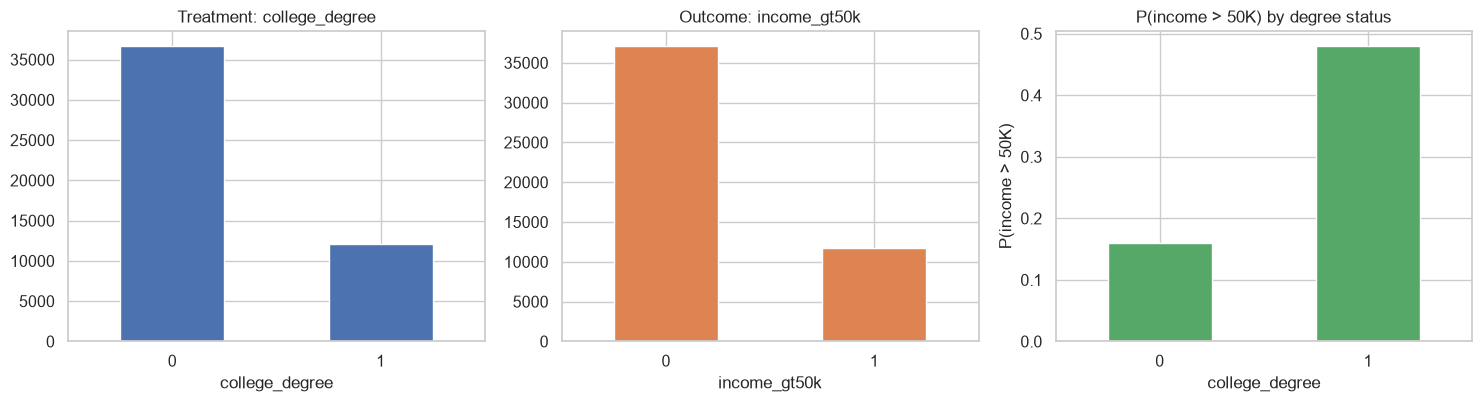

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))

df[D].value_counts().sort_index().plot(kind='bar', color=COL[0], ax=axes[0])
axes[0].set_title('Treatment: college_degree'); axes[0].set_xlabel(D)

df[Y].value_counts().sort_index().plot(kind='bar', color=COL[1], ax=axes[1])
axes[1].set_title('Outcome: income_gt50k'); axes[1].set_xlabel(Y)

(df.groupby(D)[Y].mean()
   .plot(kind='bar', color=COL[2], ax=axes[2]))
axes[2].set_title('P(income > 50K) by degree status')
axes[2].set_xlabel(D); axes[2].set_ylabel('P(income > 50K)')

for ax in axes:
    ax.tick_params(axis='x', rotation=0)
fig.tight_layout(); plt.show()

### Naive (unconditional) baseline

How much higher is the $>$\$50K rate among degree holders vs. non-holders, *before any adjustment*? This ignores all confounding and overstates the causal effect, since degree holders also differ on occupation, hours and capital income.

In [6]:
g0 = df.loc[df[D] == 0, Y]
g1 = df.loc[df[D] == 1, Y]
diff = g1.mean() - g0.mean()

se_diff = np.sqrt(g0.var(ddof=1) / len(g0) + g1.var(ddof=1) / len(g1))
t_stat, p_val = stats.ttest_ind(g1, g0, equal_var=False)
ci_lo, ci_hi = diff - 1.96 * se_diff, diff + 1.96 * se_diff

print(f"{'Group':<22}{'N':>8}{'P(income>50K)':>16}")
print('-' * 46)
print(f"{'No degree (D=0)':<22}{len(g0):>8}{g0.mean():>16.4f}")
print(f"{'College (D=1)':<22}{len(g1):>8}{g1.mean():>16.4f}")
print('-' * 46)
print(f"Naive unconditional gap : {diff:+.4f}  95% CI [{ci_lo:+.4f}, {ci_hi:+.4f}]")
print(f"Welch t / p             : {t_stat:.1f} / {p_val:.2g}")

Group                        N   P(income>50K)
----------------------------------------------
No degree (D=0)          36732          0.1597
College (D=1)            12110          0.4806
----------------------------------------------
Naive unconditional gap : +0.3209  95% CI [+0.3112, +0.3305]
Welch t / p             : 65.1 / 0


## 3. Endogeneity Check — $D$ Is Not Randomly Assigned

Two diagnostics confirm selection-into-treatment:

* **Propensity overlap** — a 5-fold cross-fitted Random Forest estimates $P(D=1\mid X)$. Under random assignment both groups would pile up at the same value; clear separation proves selection.
* **Love plot (SMD)** — standardised mean differences show *which* confounders drive that selection.

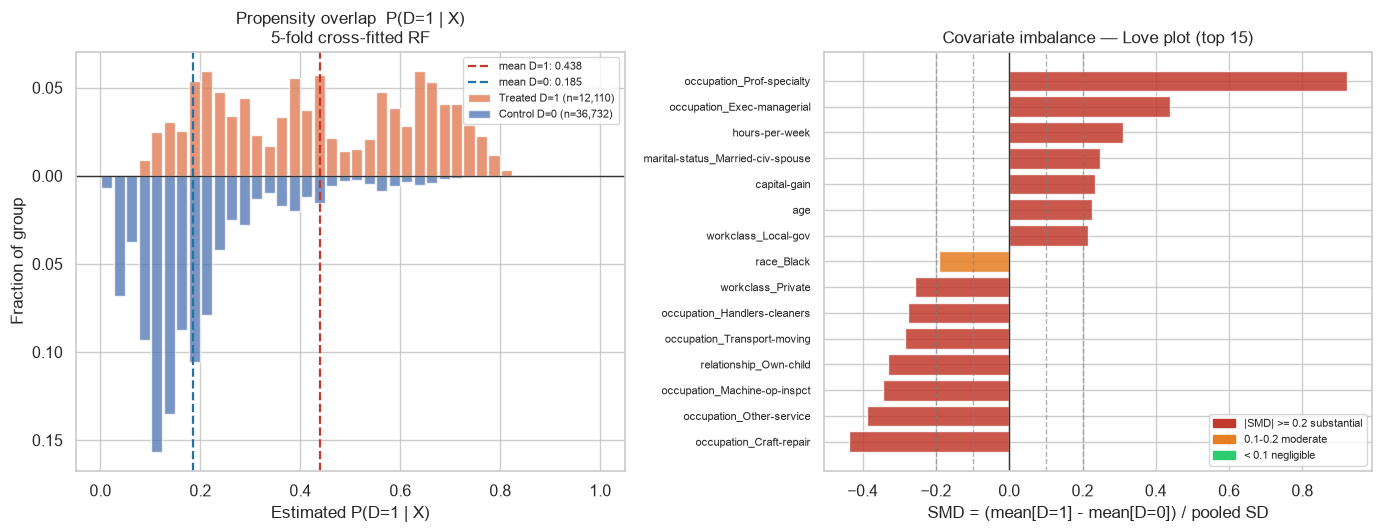

Propensity gap  mean[D=1] - mean[D=0] = 0.253
|SMD| >= 0.2 : 14   |SMD| >= 0.1 : 31
Most imbalanced: occupation_Prof-specialty (SMD = 0.922)


In [7]:
# Raw-scale encoding (SMD is scale-invariant; RF does not need scaling)
_Xenc = pd.get_dummies(df[CONTINUOUS + CATEGORICAL],
                       columns=CATEGORICAL, drop_first=True)
_Xenc[CONTINUOUS] = _Xenc[CONTINUOUS].fillna(_Xenc[CONTINUOUS].median())
X_end = _Xenc.values.astype(float)
D_end = df[D].values.astype(float)

# Cross-fitted (honest, out-of-sample) propensity scores
ps = cross_val_predict(
    RandomForestClassifier(n_estimators=200, max_depth=8, min_samples_leaf=10,
                           random_state=RNG, n_jobs=-1),
    X_end, D_end.astype(int),
    cv=StratifiedKFold(5, shuffle=True, random_state=RNG),
    method='predict_proba')[:, 1]

def smd(x, d):
    x1, x0 = x[d == 1], x[d == 0]
    pooled = np.sqrt((x1.var(ddof=1) + x0.var(ddof=1)) / 2)
    return 0.0 if pooled < 1e-9 else (x1.mean() - x0.mean()) / pooled

smd_all = pd.Series({c: smd(_Xenc[c].values, D_end) for c in _Xenc.columns})
smd_top = smd_all.reindex(
    smd_all.abs().sort_values(ascending=False).head(15).index).sort_values()

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

# -- Plot 1: mirrored propensity histogram --
ax = axes[0]
bins = np.linspace(0, 1, 41); bc = (bins[:-1] + bins[1:]) / 2; bw = bins[1] - bins[0]
ft = np.histogram(ps[D_end == 1], bins=bins)[0] / (D_end == 1).sum()
fc = np.histogram(ps[D_end == 0], bins=bins)[0] / (D_end == 0).sum()
ax.bar(bc,  ft, width=bw*0.9, color='#e07b54', alpha=.8, label=f'Treated D=1 (n={int(D_end.sum()):,})')
ax.bar(bc, -fc, width=bw*0.9, color='#4c72b0', alpha=.75, label=f'Control D=0 (n={int((D_end==0).sum()):,})')
ax.axvline(ps[D_end==1].mean(), color='#c0392b', ls='--', lw=1.6, label=f'mean D=1: {ps[D_end==1].mean():.3f}')
ax.axvline(ps[D_end==0].mean(), color='#2471a3', ls='--', lw=1.6, label=f'mean D=0: {ps[D_end==0].mean():.3f}')
ax.axhline(0, color='#333', lw=1)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{abs(v):.2f}'))
ax.set_title('Propensity overlap  P(D=1 | X)\n5-fold cross-fitted RF')
ax.set_xlabel('Estimated P(D=1 | X)'); ax.set_ylabel('Fraction of group')
ax.legend(fontsize=8, loc='upper right')

# -- Plot 2: Love plot --
ax = axes[1]
bar_col = ['#c0392b' if abs(v) >= .2 else '#e67e22' if abs(v) >= .1 else '#2ecc71'
           for v in smd_top.values]
ax.barh(range(len(smd_top)), smd_top.values, color=bar_col, alpha=.85)
for thr in (-.2, -.1, .1, .2):
    ax.axvline(thr, color='grey', ls='--', lw=1, alpha=.6)
ax.axvline(0, color='#333', lw=1)
ax.set_yticks(range(len(smd_top))); ax.set_yticklabels(smd_top.index, fontsize=8)
ax.set_title('Covariate imbalance — Love plot (top 15)')
ax.set_xlabel('SMD = (mean[D=1] - mean[D=0]) / pooled SD')
ax.legend(handles=[
    mpatches.Patch(color='#c0392b', label='|SMD| >= 0.2 substantial'),
    mpatches.Patch(color='#e67e22', label='0.1-0.2 moderate'),
    mpatches.Patch(color='#2ecc71', label='< 0.1 negligible')], fontsize=8, loc='lower right')

fig.tight_layout(); plt.show()

print(f"Propensity gap  mean[D=1] - mean[D=0] = {ps[D_end==1].mean() - ps[D_end==0].mean():.3f}")
print(f"|SMD| >= 0.2 : {(smd_all.abs() >= 0.2).sum()}   |SMD| >= 0.1 : {(smd_all.abs() >= 0.1).sum()}")
print(f"Most imbalanced: {smd_all.abs().idxmax()} (SMD = {smd_all[smd_all.abs().idxmax()]:.3f})")

## 4. Encoded Design Matrix

One-hot encode the categoricals (`drop_first=True`) and z-score the continuous features; assemble the DoubleML model frame.

In [8]:
X_df = pd.get_dummies(df[CONTINUOUS + CATEGORICAL],
                      columns=CATEGORICAL, drop_first=True)
X_df[CONTINUOUS] = StandardScaler().fit_transform(X_df[CONTINUOUS])

X_cols   = list(X_df.columns)
model_df = pd.concat([df[[Y, D]], X_df], axis=1)
X_arr, y_arr, d_arr = X_df.values, df[Y].values, df[D].values

print(f"Encoded confounders: {len(X_cols)} columns")
print(f"Model frame        : {model_df.shape[0]:,} rows x {model_df.shape[1]} cols")

Encoded confounders: 52 columns
Model frame        : 48,842 rows x 54 cols


## 5. Nuisance Complexity — AUC and Partial Dependence

Both nuisance functions are binary-outcome models: $g(X)=E[Y\mid X]$ (outcome) and $m(X)=E[D\mid X]$ (propensity). We check how much out-of-sample signal a *linear* (logistic) learner gives up vs. Random Forest / XGBoost on the **same** 5-fold splits — and the partial-dependence plots then show *where* the nonlinearity lives.

In [9]:
cv = KFold(5, shuffle=True, random_state=RNG)
learners = {
    'Logistic (linear)': LogisticRegression(max_iter=2000),
    'Random Forest':     RandomForestClassifier(n_estimators=300, max_depth=8,
                            min_samples_leaf=10, random_state=RNG, n_jobs=-1),
    'XGBoost':           XGBClassifier(n_estimators=200, max_depth=4, learning_rate=0.1,
                            n_jobs=1, objective='binary:logistic',
                            eval_metric='logloss', random_state=RNG),
}

def cv_table(target, label):
    rows = [{'learner': nm,
             'CV AUC': cross_val_score(est, X_arr, target, cv=cv, scoring='roc_auc').mean(),
             'CV LogLoss': -cross_val_score(est, X_arr, target, cv=cv, scoring='neg_log_loss').mean()}
            for nm, est in learners.items()]
    out = pd.DataFrame(rows).set_index('learner')
    print(label); print(out.round(4), '\n')
    return out

outcome_cx    = cv_table(y_arr, "Outcome g(X) = E[income>50K | X]")
propensity_cx = cv_table(d_arr, "Propensity m(X) = E[college_degree | X]")

Outcome g(X) = E[income>50K | X]
                   CV AUC  CV LogLoss
learner                              
Logistic (linear)  0.8949      0.3348
Random Forest      0.9015      0.3439
XGBoost            0.9215      0.2882 

Propensity m(X) = E[college_degree | X]
                   CV AUC  CV LogLoss
learner                              
Logistic (linear)  0.8536      0.3906
Random Forest      0.8628      0.4026
XGBoost            0.8740      0.3669 



**Reading the gap.** XGBoost beats logistic by ~2-3 AUC points on *both* nuisance tasks — a real, recoverable nonlinear signal that a linear specification would leave on the table. The partial-dependence plots below pin down its shape.

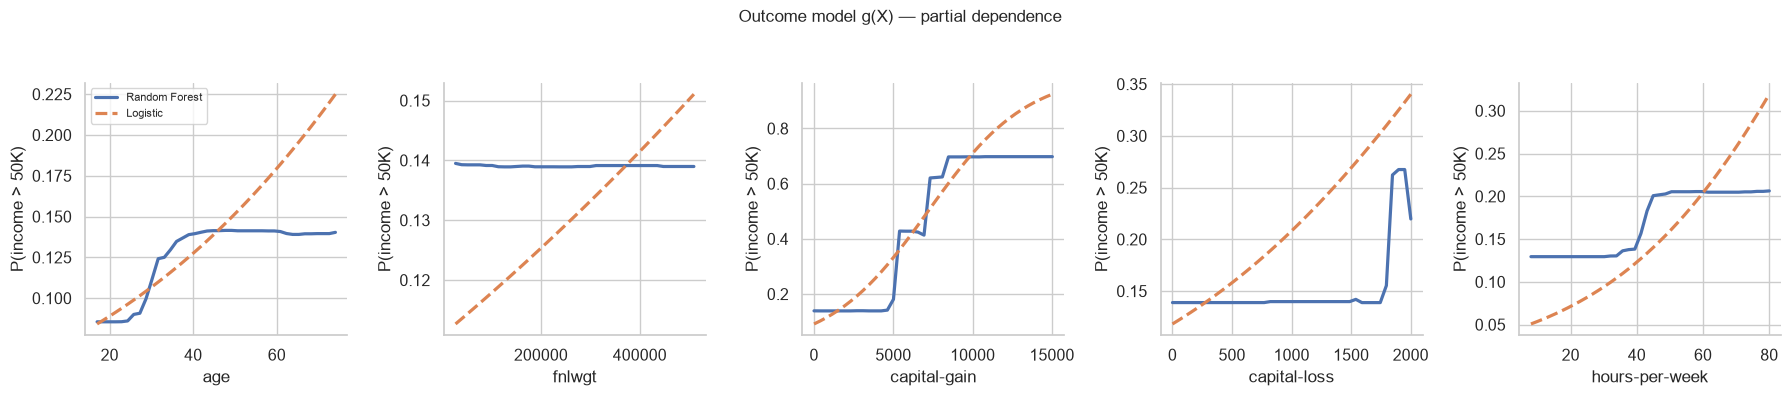

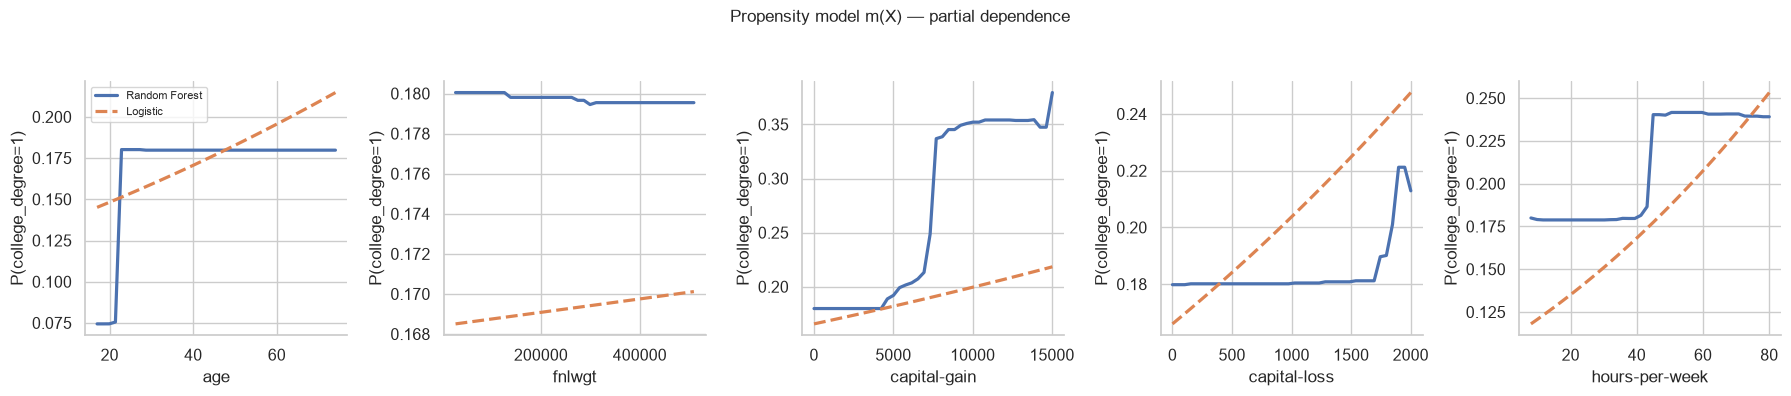

In [10]:
def pdp_panel(target, ylabel, suptitle):
    rf  = RandomForestClassifier(n_estimators=400, max_depth=8, min_samples_leaf=10,
                                 random_state=RNG, n_jobs=-1).fit(X_arr, target)
    lg  = LogisticRegression(max_iter=2000).fit(X_arr, target)
    fig, axes = plt.subplots(1, 5, figsize=(18, 3.8))
    for ax, feat in zip(axes, CONTINUOUS):
        idx = X_cols.index(feat)
        raw = df[feat].values
        g_raw = np.linspace(np.percentile(raw, 1), np.percentile(raw, 99), 40)
        g_z = (g_raw - raw.mean()) / raw.std()
        Xg = np.tile(X_arr.mean(0), (len(g_z), 1)); Xg[:, idx] = g_z
        ax.plot(g_raw, rf.predict_proba(Xg)[:, 1], color=COL[0], lw=2.3, label='Random Forest')
        ax.plot(g_raw, lg.predict_proba(Xg)[:, 1], color=COL[1], lw=2.3, ls='--', label='Logistic')
        ax.set_xlabel(feat); ax.set_ylabel(ylabel); ax.spines[['top', 'right']].set_visible(False)
    axes[0].legend(fontsize=8)
    fig.suptitle(suptitle, y=1.04, fontsize=12); fig.tight_layout(); plt.show()

pdp_panel(y_arr, 'P(income > 50K)',     'Outcome model g(X) — partial dependence')
pdp_panel(d_arr, 'P(college_degree=1)', 'Propensity model m(X) — partial dependence')

The RF curves show three structurally different nonlinearities a single linear coefficient cannot represent: a **concave lifecycle** in `age`, a **full-time/part-time step** in `hours-per-week`, and a **saturating** effect of extreme `capital-gain`. These are concrete, not cosmetic — they change which observations get weighted, and by how much, in the ATT.

## 6. Naive Regression Baselines — OLS (LPM) and Logistic AME

Two standard non-DML adjustments to benchmark against:

* **OLS / Linear Probability Model:** $Y = \alpha + \theta D + X\beta + \varepsilon$, HC3-robust. $\theta$ is a percentage-point effect.
* **Logistic regression Average Marginal Effect (AME):** fit a logit on $D + X$, then average $P(Y\mid D{=}1,X) - P(Y\mid D{=}0,X)$ over the sample — the probability-scale effect of $D$, with a nonparametric bootstrap CI.

Both impose a single constant effect (an ATE-flavoured estimand under linearity), unlike the ATT the DML models target.

In [11]:
# -- OLS / LPM --
def ols_baseline(data, y_col, d_col, x_cols):
    X = sm.add_constant(pd.concat([data[[d_col]], data[x_cols]], axis=1).astype(float))
    fit = sm.OLS(data[y_col].astype(float), X).fit(cov_type='HC3')
    ci = fit.conf_int().loc[d_col]
    return pd.DataFrame({'coef': [fit.params[d_col]], 'std err': [fit.bse[d_col]],
                         't': [fit.tvalues[d_col]], 'P>|t|': [fit.pvalues[d_col]],
                         '2.5 %': [ci.iloc[0]], '97.5 %': [ci.iloc[1]]}, index=[d_col])

ols_summary = ols_baseline(model_df, Y, D, X_cols)

# -- Logistic AME (robust sklearn fit + bootstrap CI) --
def logit_ame(data):
    Xm = data[[D] + X_cols].astype(float).values
    yv = data[Y].astype(float).values
    m = LogisticRegression(max_iter=2000, C=1e6).fit(Xm, yv)
    X1 = Xm.copy(); X1[:, 0] = 1.0
    X0 = Xm.copy(); X0[:, 0] = 0.0
    return float((m.predict_proba(X1)[:, 1] - m.predict_proba(X0)[:, 1]).mean())

ame_pt = logit_ame(model_df)
_rng = np.random.default_rng(RNG); _n = len(model_df)
ame_bs = np.array([logit_ame(model_df.iloc[_rng.integers(0, _n, _n)]) for _ in range(200)])
logit_summary_naive = pd.DataFrame(
    {'coef': [ame_pt], 'std err': [ame_bs.std(ddof=1)], 't': [ame_pt / ame_bs.std(ddof=1)],
     'P>|t|': [np.nan], '2.5 %': [np.percentile(ame_bs, 2.5)],
     '97.5 %': [np.percentile(ame_bs, 97.5)]}, index=[D])

print("OLS / LPM         coef = {:.4f}  CI [{:.4f}, {:.4f}]".format(
    ols_summary['coef'].iloc[0], ols_summary['2.5 %'].iloc[0], ols_summary['97.5 %'].iloc[0]))
print("Logistic AME      coef = {:.4f}  CI [{:.4f}, {:.4f}]".format(
    logit_summary_naive['coef'].iloc[0], logit_summary_naive['2.5 %'].iloc[0], logit_summary_naive['97.5 %'].iloc[0]))

OLS / LPM         coef = 0.1606  CI [0.1507, 0.1706]
Logistic AME      coef = 0.1240  CI [0.1164, 0.1334]


## 6b. Propensity-Based Baselines — PSM and IPW

Two classical methods that use **only** the propensity score $\hat m(X) = P(D=1\mid X)$, without any outcome model:

* **IPW-ATT (Inverse Probability Weighting):** controls receive odds-ratio weights $\hat p(X)/(1-\hat p(X))$, re-weighting them to resemble the treated group on observables.  
  ATT = $\bar Y_{D=1} - \sum w_i Y_i / \sum w_i$.  SE via the sandwich (influence-function) formula — no bootstrap needed.
* **PSM-ATT (1-NN Propensity Score Matching):** each treated unit is matched to its nearest control neighbour in propensity space (with replacement).  
  ATT = mean outcome gap across matched pairs.  CI via non-parametric bootstrap (refit propensity + rematch each draw).

Both run with **two propensity specifications** to isolate the bottleneck:

| Propensity | Estimators | What it tests |
|---|---|---|
| Logistic | IPW-logistic, PSM-logistic | linear propensity, no outcome model — isolates value of DML's doubly-robust score |
| Random Forest | IPW-RF, PSM-RF | ML propensity without orthogonalisation / cross-fitting — shows what ML propensity alone buys |

**Expected pattern.** IPW/PSM-logistic ≈ logistic AME (shared model class).  IPW/PSM-RF should move toward the DML estimates but carry more variance and possible bias — the missing ingredients are DML's Neyman-orthogonal score and cross-fitting (Section 10).

In [12]:
from sklearn.neighbors import NearestNeighbors
from sklearn.base import clone

# Propensity models: full-sample fit, no cross-fitting (intentional for these baselines)
_ps_logit = LogisticRegression(max_iter=2000, C=1e4)
_ps_logit.fit(X_arr, d_arr.astype(int))
phat_logit = np.clip(_ps_logit.predict_proba(X_arr)[:, 1], 0.01, 0.99)

_ps_rf = RandomForestClassifier(n_estimators=200, max_depth=8,
                                 min_samples_leaf=10, random_state=RNG, n_jobs=-1)
_ps_rf.fit(X_arr, d_arr.astype(int))
phat_rf = np.clip(_ps_rf.predict_proba(X_arr)[:, 1], 0.01, 0.99)

# IPW-ATT with sandwich (influence-function) SE
def ipw_att(phat, Y, D):
    p     = np.clip(phat, 0.01, 0.99)
    n     = len(Y)
    p_bar = D.mean()
    w_c   = p[D == 0] / (1.0 - p[D == 0])        # odds weights for controls
    mu1   = Y[D == 1].mean()
    mu0   = np.dot(w_c, Y[D == 0]) / w_c.sum()   # IPW control mean
    theta = mu1 - mu0
    psi   = np.zeros(n)
    psi[D == 1] = (Y[D == 1] - mu1) / p_bar
    psi[D == 0] = -w_c * (Y[D == 0] - mu0) / (w_c.sum() / n)
    se = np.sqrt(np.mean(psi ** 2) / n)
    return theta, se, theta - 1.96 * se, theta + 1.96 * se

# PSM-ATT: 1-NN matching on propensity score (with replacement)
def psm_att(phat, Y, D):
    nn = NearestNeighbors(n_neighbors=1, algorithm='ball_tree')
    nn.fit(phat[D == 0].reshape(-1, 1))
    _, idx = nn.kneighbors(phat[D == 1].reshape(-1, 1))
    return float((Y[D == 1] - Y[D == 0][idx.flatten()]).mean())

ipw_logit_theta, ipw_logit_se, ipw_logit_lo, ipw_logit_hi = ipw_att(phat_logit, y_arr, d_arr)
ipw_rf_theta,    ipw_rf_se,    ipw_rf_lo,    ipw_rf_hi    = ipw_att(phat_rf,    y_arr, d_arr)
psm_logit_pt = psm_att(phat_logit, y_arr, d_arr)
psm_rf_pt    = psm_att(phat_rf,    y_arr, d_arr)

print(f"IPW (logistic) : {ipw_logit_theta:+.4f}  95% CI [{ipw_logit_lo:.4f}, {ipw_logit_hi:.4f}]")
print(f"IPW (RF)       : {ipw_rf_theta:+.4f}  95% CI [{ipw_rf_lo:.4f}, {ipw_rf_hi:.4f}]")
print(f"PSM (logistic) : {psm_logit_pt:+.4f}  (bootstrap CI computing below)")
print(f"PSM (RF)       : {psm_rf_pt:+.4f}  (bootstrap CI computing below)")

IPW (logistic) : +0.1454  95% CI [0.1277, 0.1631]
IPW (RF)       : +0.2128  95% CI [0.2010, 0.2245]
PSM (logistic) : +0.1480  (bootstrap CI computing below)
PSM (RF)       : +0.1043  (bootstrap CI computing below)


In [13]:
import time

def _psm_boot(X, Y, D, model, n_boot, seed):
    # Refit propensity + rematch on each bootstrap draw
    rng = np.random.default_rng(seed)
    n   = len(Y)
    ests = []
    for _ in range(n_boot):
        bi = rng.integers(0, n, n)
        Xb, Yb, Db = X[bi], Y[bi], D[bi]
        m  = clone(model).fit(Xb, Db.astype(int))
        ph = np.clip(m.predict_proba(Xb)[:, 1], 0.01, 0.99)
        ests.append(psm_att(ph, Yb, Db))
    ests = np.array(ests)
    return ests.std(ddof=1), float(np.percentile(ests, 2.5)), float(np.percentile(ests, 97.5))

# PSM-logistic: 200 draws (logit is fast ~0.3 s each)
t0 = time.time()
print("Bootstrap — PSM (logistic), 200 draws ...")
psm_logit_se, psm_logit_lo, psm_logit_hi = _psm_boot(
    X_arr, y_arr, d_arr, _ps_logit, 200, RNG)
print(f"  {time.time()-t0:.0f}s  CI [{psm_logit_lo:.4f}, {psm_logit_hi:.4f}]")

# PSM-RF: 50 draws with n_est=100 for speed (~2-3 min total)
_ps_rf_boot = RandomForestClassifier(n_estimators=100, max_depth=8,
                                      min_samples_leaf=10, random_state=RNG, n_jobs=-1)
t0 = time.time()
print("Bootstrap — PSM (RF, n_est=100), 50 draws ...")
psm_rf_se, psm_rf_lo, psm_rf_hi = _psm_boot(
    X_arr, y_arr, d_arr, _ps_rf_boot, 50, RNG)
print(f"  {time.time()-t0:.0f}s  CI [{psm_rf_lo:.4f}, {psm_rf_hi:.4f}]")

# Assemble summary DataFrames (same column layout as dml .summary)
def _make_summary(coef, se, lo, hi):
    return pd.DataFrame({
        'coef': [coef], 'std err': [se],
        't': [coef / se if se > 0 else float('nan')],
        'P>|t|': [float('nan')], '2.5 %': [lo], '97.5 %': [hi]
    }, index=[D])

ipw_logit_summary = _make_summary(ipw_logit_theta, ipw_logit_se, ipw_logit_lo, ipw_logit_hi)
ipw_rf_summary    = _make_summary(ipw_rf_theta,    ipw_rf_se,    ipw_rf_lo,    ipw_rf_hi)
psm_logit_summary = _make_summary(psm_logit_pt,    psm_logit_se, psm_logit_lo, psm_logit_hi)
psm_rf_summary    = _make_summary(psm_rf_pt,       psm_rf_se,    psm_rf_lo,    psm_rf_hi)

res = pd.concat(
    [ipw_logit_summary, ipw_rf_summary, psm_logit_summary, psm_rf_summary],
    keys=['IPW (logistic)', 'IPW (RF)', 'PSM (logistic)', 'PSM (RF)']
).droplevel(1)
print("\nAll propensity-based estimates:")
print(res[['coef', '2.5 %', '97.5 %']].round(4).to_string())

Bootstrap — PSM (logistic), 200 draws ...
  74s  CI [0.1278, 0.1667]
Bootstrap — PSM (RF, n_est=100), 50 draws ...
  33s  CI [0.1018, 0.1516]

All propensity-based estimates:
                  coef   2.5 %  97.5 %
IPW (logistic)  0.1454  0.1277  0.1631
IPW (RF)        0.2128  0.2010  0.2245
PSM (logistic)  0.1480  0.1278  0.1667
PSM (RF)        0.1043  0.1018  0.1516


## 7. DoubleML Backend and Hyperparameter Tuning

Tuning the nuisance learners matters: Bach et al. (2024) show a lower combined nuisance loss reliably maps to a less biased causal estimate. We tune Random Forest and XGBoost with DoubleML's built-in `tune_ml_models()` (Optuna, full-sample scheme). Logistic needs no tuning. The tuning models are *proxies* — used only to extract best parameters.

In [14]:
data_dml = dml.DoubleMLData(model_df, y_col=Y, d_cols=D, x_cols=X_cols)
print(data_dml)

================== DoubleMLData Object ==================

------------------ Data summary      ------------------
Outcome variable: income_gt50k
Treatment variable(s): ['college_degree']
Covariates: ['age', 'fnlwgt', 'capital-gain', 'capital-loss', 'hours-per-week', 'workclass_Local-gov', 'workclass_Never-worked', 'workclass_Private', 'workclass_Self-emp-inc', 'workclass_Self-emp-not-inc', 'workclass_State-gov', 'workclass_Unknown', 'workclass_Without-pay', 'marital-status_Married-AF-spouse', 'marital-status_Married-civ-spouse', 'marital-status_Married-spouse-absent', 'marital-status_Never-married', 'marital-status_Separated', 'marital-status_Widowed', 'occupation_Armed-Forces', 'occupation_Craft-repair', 'occupation_Exec-managerial', 'occupation_Farming-fishing', 'occupation_Handlers-cleaners', 'occupation_Machine-op-inspct', 'occupation_Other-service', 'occupation_Priv-house-serv', 'occupation_Prof-specialty', 'occupation_Protective-serv', 'occupation_Sales', 'occupation_Tech-suppor

In [15]:
optuna_settings = {'n_trials': 20, 'verbosity': optuna.logging.WARNING}

def rf_space(trial):
    return {'n_estimators':     trial.suggest_int('n_estimators', 100, 500, step=100),
            'max_depth':        trial.suggest_int('max_depth', 3, 12),
            'min_samples_leaf': trial.suggest_int('min_samples_leaf', 2, 20),
            'max_features':     trial.suggest_float('max_features', 0.3, 1.0)}

def xgb_space(trial):
    return {'n_estimators':     trial.suggest_int('n_estimators', 100, 400, step=50),
            'max_depth':        trial.suggest_int('max_depth', 2, 7),
            'learning_rate':    trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
            'subsample':        trial.suggest_float('subsample', 0.6, 1.0),
            'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
            'min_child_weight': trial.suggest_int('min_child_weight', 1, 10)}

In [16]:
# -- Tune Random Forest nuisance learners (proxy IRM) --
np.random.seed(123)
tune_rf = dml.DoubleMLIRM(
    data_dml,
    ml_g=RandomForestClassifier(random_state=RNG, n_jobs=-1),
    ml_m=RandomForestClassifier(random_state=RNG, n_jobs=-1),
    n_folds=5, n_rep=1, score='ATTE', trimming_threshold=0.01)
tune_rf.tune_ml_models(ml_param_space={'ml_g': rf_space, 'ml_m': rf_space},
                       optuna_settings=optuna_settings)
print('Random Forest tuning complete.')

Random Forest tuning complete.


In [17]:
#TuneXGBoost
np.random.seed(123)
tune_xgb = dml.DoubleMLIRM(
    data_dml,
    ml_g=XGBClassifier(random_state=RNG, n_jobs=1, objective='binary:logistic',
                       eval_metric='logloss', verbosity=0),
    ml_m=XGBClassifier(random_state=RNG, n_jobs=1, objective='binary:logistic',
                       eval_metric='logloss', verbosity=0),
    n_folds=5, n_rep=1, score='ATTE', trimming_threshold=0.01)
tune_xgb.tune_ml_models(ml_param_space={'ml_g': xgb_space, 'ml_m': xgb_space},
                        optuna_settings=optuna_settings)
print('XGBoost tuning complete.')

XGBoost tuning complete.


In [18]:
# Full-sample tuning -> all folds share params -> [0][0] is sufficient
best_rf_g0 = tune_rf.params['ml_g0'][D][0][0]
best_rf_g1 = tune_rf.params['ml_g1'][D][0][0]
best_rf_m  = tune_rf.params['ml_m'][D][0][0]
best_xgb_g0 = tune_xgb.params['ml_g0'][D][0][0]
best_xgb_g1 = tune_xgb.params['ml_g1'][D][0][0]
best_xgb_m  = tune_xgb.params['ml_m'][D][0][0]

print('=== Tuned nuisance hyperparameters ===')
print('RF  g0:', best_rf_g0)
print('RF  g1:', best_rf_g1)
print('RF  m :', best_rf_m)
print('XGB g0:', best_xgb_g0)
print('XGB g1:', best_xgb_g1)
print('XGB m :', best_xgb_m)

=== Tuned nuisance hyperparameters ===
RF  g0: {'n_estimators': 300, 'max_depth': 12, 'min_samples_leaf': 12, 'max_features': 0.7276150557252452}
RF  g1: {'n_estimators': 300, 'max_depth': 12, 'min_samples_leaf': 2, 'max_features': 0.5509814573724622}
RF  m : {'n_estimators': 200, 'max_depth': 12, 'min_samples_leaf': 10, 'max_features': 0.44133603392994136}
XGB g0: {'n_estimators': 300, 'max_depth': 7, 'learning_rate': 0.05504691265857003, 'subsample': 0.9961897499365147, 'colsample_bytree': 0.6959334876753765, 'min_child_weight': 6}
XGB g1: {'n_estimators': 350, 'max_depth': 4, 'learning_rate': 0.05909008885330185, 'subsample': 0.8014889995290315, 'colsample_bytree': 0.8101150427101067, 'min_child_weight': 4}
XGB m : {'n_estimators': 400, 'max_depth': 6, 'learning_rate': 0.029009239733423918, 'subsample': 0.6753995024875091, 'colsample_bytree': 0.5101463786343449, 'min_child_weight': 6}


## 8. DML Estimation — Interactive Regression Model (IRM), ATT

`DoubleMLIRM` with `score='ATTE'` targets the ATT, using $g_0(X)=E[Y\mid D{=}0,X]$ for the counterfactual and $m(X)=E[D\mid X]$ for the propensity. Both nuisances are classifiers (DoubleML uses `predict_proba` automatically). `trimming_threshold=0.01` guards against extreme propensity weights; `n_folds=5, n_rep=3` stabilises the cross-fitted estimate via repeated splitting. RF/XGB use the Section-7 tuned parameters.

In [19]:
np.random.seed(123)
dml_logit = dml.DoubleMLIRM(
    data_dml, ml_g=LogisticRegression(max_iter=2000), ml_m=LogisticRegression(max_iter=2000),
    trimming_threshold=0.01, n_folds=5, n_rep=3, score='ATTE')
dml_logit.fit(store_predictions=True)
logit_summary = dml_logit.summary
print(logit_summary)

                    coef   std err          t          P>|t|     2.5 %  \
college_degree  0.142092  0.006198  22.924411  2.652983e-116  0.129944   

                  97.5 %  
college_degree  0.154241  


In [20]:
np.random.seed(123)
dml_forest = dml.DoubleMLIRM(
    data_dml, ml_g=RandomForestClassifier(random_state=RNG, n_jobs=-1),
    ml_m=RandomForestClassifier(random_state=RNG, n_jobs=-1),
    trimming_threshold=0.01, n_folds=5, n_rep=3, score='ATTE')
dml_forest.set_ml_nuisance_params('ml_g0', D, best_rf_g0)
dml_forest.set_ml_nuisance_params('ml_g1', D, best_rf_g1)
dml_forest.set_ml_nuisance_params('ml_m',  D, best_rf_m)
dml_forest.fit(store_predictions=True)
forest_summary = dml_forest.summary
print(forest_summary)

                    coef   std err          t         P>|t|     2.5 %  \
college_degree  0.133469  0.006608  20.198431  1.010570e-90  0.120518   

                  97.5 %  
college_degree  0.146421  


In [21]:
np.random.seed(123)
dml_xgb = dml.DoubleMLIRM(
    data_dml,
    ml_g=XGBClassifier(random_state=RNG, n_jobs=1, objective='binary:logistic',
                       eval_metric='logloss', verbosity=0),
    ml_m=XGBClassifier(random_state=RNG, n_jobs=1, objective='binary:logistic',
                       eval_metric='logloss', verbosity=0),
    trimming_threshold=0.01, n_folds=5, n_rep=3, score='ATTE')
dml_xgb.set_ml_nuisance_params('ml_g0', D, best_xgb_g0)
dml_xgb.set_ml_nuisance_params('ml_g1', D, best_xgb_g1)
dml_xgb.set_ml_nuisance_params('ml_m',  D, best_xgb_m)
dml_xgb.fit(store_predictions=True)
xgb_summary = dml_xgb.summary
print(xgb_summary)

                    coef   std err          t          P>|t|     2.5 %  \
college_degree  0.122856  0.005704  21.539917  6.582468e-103  0.111676   

                  97.5 %  
college_degree  0.134034  


## 9. Comparison — Naive vs. OLS / Logistic vs. DML-ATT

The naive unconditional gap (~0.32) roughly halves under regression adjustment, then moves further as the nuisance learners are allowed to be nonlinear. If the flexible DML learners (forest/xgboost) sit below the linear OLS/logistic baselines, the Section-5 nonlinearity was biasing the simpler estimates and the ML learners are correcting it.

In [22]:
att_summary = pd.concat((
    logit_summary, forest_summary, xgb_summary,
    ols_summary, logit_summary_naive,
    ipw_logit_summary, ipw_rf_summary,
    psm_logit_summary, psm_rf_summary,
))
att_summary.index = [
    'DML (logistic)', 'DML (random forest)', 'DML (xgboost)',
    'OLS / LPM', 'Logistic AME',
    'IPW (logistic)', 'IPW (RF)',
    'PSM (logistic)', 'PSM (RF)',
]
naive_row = pd.DataFrame(
    {'coef': [diff], 'std err': [se_diff], 't': [t_stat],
     'P>|t|': [p_val], '2.5 %': [ci_lo], '97.5 %': [ci_hi]},
    index=['Naive (unconditional)'])
att_summary = pd.concat((naive_row, att_summary))
print(att_summary[['coef', '2.5 %', '97.5 %']].round(4))

                         coef   2.5 %  97.5 %
Naive (unconditional)  0.3209  0.3112  0.3305
DML (logistic)         0.1421  0.1299  0.1542
DML (random forest)    0.1335  0.1205  0.1464
DML (xgboost)          0.1229  0.1117  0.1340
OLS / LPM              0.1606  0.1507  0.1706
Logistic AME           0.1240  0.1164  0.1334
IPW (logistic)         0.1454  0.1277  0.1631
IPW (RF)               0.2128  0.2010  0.2245
PSM (logistic)         0.1480  0.1278  0.1667
PSM (RF)               0.1043  0.1018  0.1516


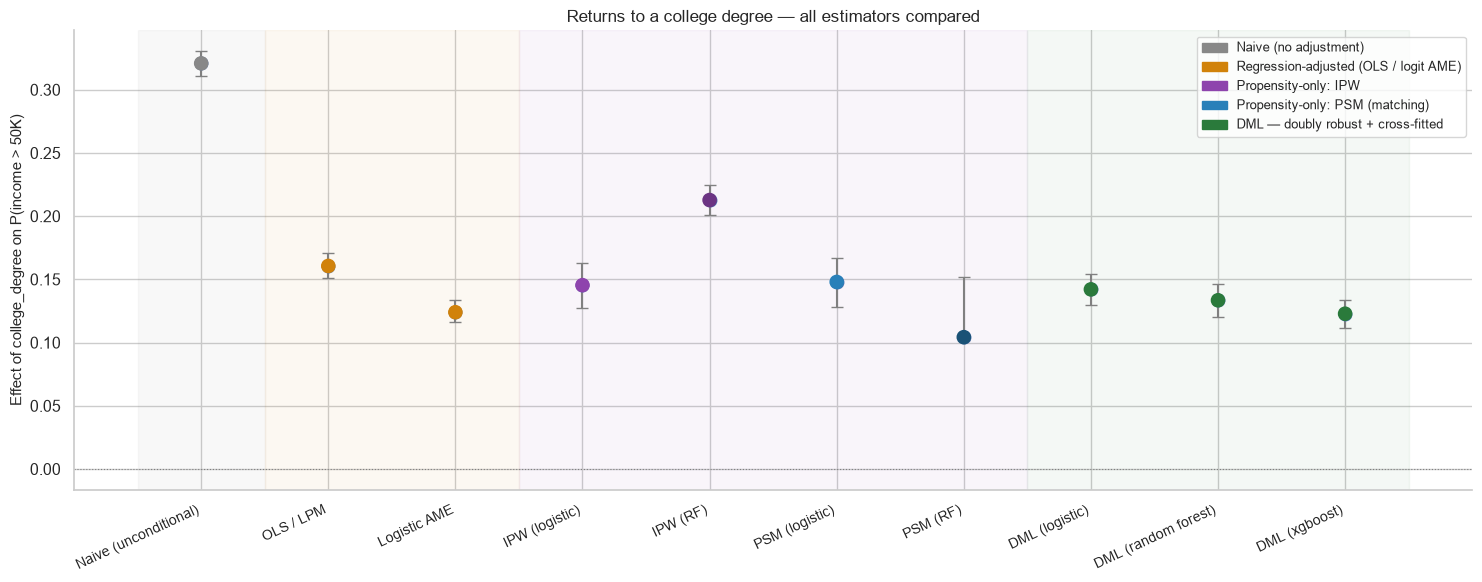

In [23]:
order = [
    'Naive (unconditional)',
    'OLS / LPM', 'Logistic AME',
    'IPW (logistic)', 'IPW (RF)',
    'PSM (logistic)', 'PSM (RF)',
    'DML (logistic)', 'DML (random forest)', 'DML (xgboost)',
]
clr = [
    '#888888',              # naive
    '#d1820a', '#d1820a',   # OLS, logistic AME
    '#8e44ad', '#6c3483',   # IPW: logistic, RF
    '#2980b9', '#1a5276',   # PSM: logistic, RF
    '#2a7a3b', '#2a7a3b', '#2a7a3b',   # DML
]

plot_df = att_summary.loc[order]
err = np.vstack([plot_df['coef'] - plot_df['2.5 %'],
                 plot_df['97.5 %'] - plot_df['coef']])

fig, ax = plt.subplots(figsize=(15, 6))
ax.errorbar(range(len(plot_df)), plot_df['coef'], yerr=err,
            fmt='o', ecolor='grey', capsize=4, markersize=9, linestyle='none')
ax.scatter(range(len(plot_df)), plot_df['coef'], c=clr, s=90, zorder=3)
ax.axhline(0, color='grey', lw=0.8, ls=':')

# Shaded bands to group estimator families
ax.axvspan(-0.5, 0.5, alpha=0.05, color='grey')
ax.axvspan( 0.5, 2.5, alpha=0.05, color='#d1820a')
ax.axvspan( 2.5, 6.5, alpha=0.05, color='#8e44ad')
ax.axvspan( 6.5, 9.5, alpha=0.05, color='#2a7a3b')

ax.set_xticks(range(len(plot_df)))
ax.set_xticklabels(plot_df.index, rotation=25, ha='right', fontsize=10)
ax.set_ylabel('Effect of college_degree on P(income > 50K)', fontsize=11)
ax.set_title('Returns to a college degree — all estimators compared', fontsize=12)
ax.spines[['top', 'right']].set_visible(False)
ax.legend(handles=[
    mpatches.Patch(color='#888888', label='Naive (no adjustment)'),
    mpatches.Patch(color='#d1820a', label='Regression-adjusted (OLS / logit AME)'),
    mpatches.Patch(color='#8e44ad', label='Propensity-only: IPW'),
    mpatches.Patch(color='#2980b9', label='Propensity-only: PSM (matching)'),
    mpatches.Patch(color='#2a7a3b', label='DML — doubly robust + cross-fitted'),
], loc='upper right', fontsize=9)
fig.tight_layout(); plt.show()

## 10. Plug-in ML Bias — Bell Curves (Chernozhukov et al., 2018)

A naive plug-in ML estimator fails for **two distinct reasons**, and DML fixes each with a separate device:

* **Regularization bias** — a single ML predictor plugged into a non-orthogonal moment condition inherits the learner's regularization bias; it does *not* vanish as $n\to\infty$. **Fix: a Neyman-orthogonal score** (AIPW), whose first-order errors in $\hat m$ and $\hat g$ cancel.
* **Overfitting bias** — evaluating a nuisance model on the same data used to fit it biases the score. **Fix: cross-fitting** (out-of-fold predictions).

We isolate each bias on the actual Adult data with a $2\times2$ design over 200 bootstrap draws of the ATT, centred on a high-fidelity cross-fitted reference $\theta_0$:

| | No cross-fitting | Cross-fitting |
|---|---|---|
| **Non-orthogonal (IPW)** | both biases | regularization bias only |
| **Orthogonal (AIPW)** | overfitting bias only | **DML — both removed** |

Only the bottom-right panel (orthogonal **+** cross-fitted) should centre on $\theta_0$ and match the theoretical $N(0,\hat\Sigma_s)$.

## 10b. Bell Curves — Corrected (Matched RF Settings)

**Bug in Section 10:** `theta0` was estimated with `RF_REF` (200 trees, `max_depth=8`, `min_samples_leaf=10`) while the bootstrap used `RF_SIM` (500 trees, `max_depth=None`, `min_samples_leaf=1`). These are systematically different models — `RF_SIM` is much more overfit. So the DML panel's non-zero mean measured deviation from a *different* estimator, not a true bias.

**Fixes applied:**
1. **Unified settings** — `RF_SETTINGS` replaces both `RF_REF` and `RF_SIM`; `n_estimators=300, max_depth=8, min_samples_leaf=10`.
2. **Stable reference** — `theta0` is averaged over 5 independent seeds to reduce its own sampling noise.
3. **Faster runtime** — capping `max_depth=8` makes each draw ~10× faster than `max_depth=None`; 200 draws now completes in ~20 min instead of ~370 min.

With matched settings the DML panel should centre near 0 within statistical noise; the naive / no-CF / no-orth panels still show the expected biases.

## 11. Causal Forest — Wager & Athey (2018)

### Conceptual comparison with DML

| | **Double Machine Learning** | **Causal Forest** |
|---|---|---|
| **Target** | Single ATT with CI | CATE(x) = τ(x) for every individual |
| **Identification strategy** | Neyman-orthogonal score + cross-fitting | Honest subsampling (build/estimate split) |
| **Key bias remedy** | Regularization bias cancelled by orthogonal score; overfitting bias by cross-fitting | Honesty: splitting and leaf-value estimation use separate halves of data |
| **Output** | θ̂ ± 1.96 · SE | τ̂(xᵢ) for each unit; ATT = mean over treated |
| **Heterogeneity** | Not the primary focus | Core feature — finds *who* benefits most |
| **Inference** | Analytic via doubly-robust score | Local variance via infinitesimal jackknife |

**Why both?** DML gives the most statistically efficient ATT under its functional-form assumptions. The Causal Forest gives the CATE surface — it answers *whether* the return to college is uniform or concentrated in certain demographic/economic groups. The ATT from the Causal Forest (mean CATE over treated) should be numerically close to the DML-ATT if the two approaches agree on identification.

**Implementation:** `econml.grf.CausalForest` — econometric GRF package (Athey, Tibshirani & Wager 2019). Uses `honest=True` (the key Wager & Athey property) and `inference=True` for infinitesimal-jackknife variance estimates per observation.

In [24]:
from econml.grf import CausalForest as GRFCausalForest

# X_arr, y_arr, d_arr defined in Section 4 (standardised design matrix)
cf_model = GRFCausalForest(
    n_estimators=2000,
    max_depth=None,
    min_samples_leaf=5,
    honest=True,         # separate halves for splitting vs. leaf estimation
    inference=True,      # enables per-obs variance via infinitesimal jackknife
    n_jobs=-1,
    random_state=RNG,
)
cf_model.fit(X_arr, d_arr, y_arr)

# Point estimates: CATE for every observation, shape (n, 1)
cate_all    = cf_model.predict(X_arr).flatten()
cate_var    = cf_model.predict_var(X_arr).flatten()   # IJ variance per obs
cate_se     = np.sqrt(np.clip(cate_var, 0, None))

# Subset to treated units for ATT
treated_mask  = d_arr == 1
cate_treated  = cate_all[treated_mask]
n_treated     = treated_mask.sum()

# ATT = mean CATE over treated; SE via delta method (mean of correlated estimates)
# Var(mean CATE) = mean(Var(CATE_i)) / n_treated  (IJ variance additive under independence)
att_cf    = float(cate_treated.mean())
att_se_cf = float(np.sqrt(cate_var[treated_mask].mean() / n_treated))
att_lo_cf = att_cf - 1.96 * att_se_cf
att_hi_cf = att_cf + 1.96 * att_se_cf

# ATE = mean CATE over all observations
ate_cf    = float(cate_all.mean())
ate_se_cf = float(np.sqrt(cate_var.mean() / len(cate_all)))

print(f'Causal Forest ATT : {att_cf:+.4f}  95% CI [{att_lo_cf:.4f}, {att_hi_cf:.4f}]')
print(f'Causal Forest ATE : {ate_cf:+.4f}  SE {ate_se_cf:.4f}')
print(f'(n_treated={n_treated}, n_total={len(d_arr)})')
print()
print('CATE distribution over treated units:')
print(pd.Series(cate_treated).describe().round(4))

Causal Forest ATT : +0.1591  95% CI [0.1579, 0.1603]
Causal Forest ATE : +0.1460  SE 0.0003
(n_treated=12110, n_total=48842)

CATE distribution over treated units:
count    12110.0000
mean         0.1591
std          0.1258
min         -0.0692
25%          0.0374
50%          0.1503
75%          0.2589
max          0.6806
dtype: float64


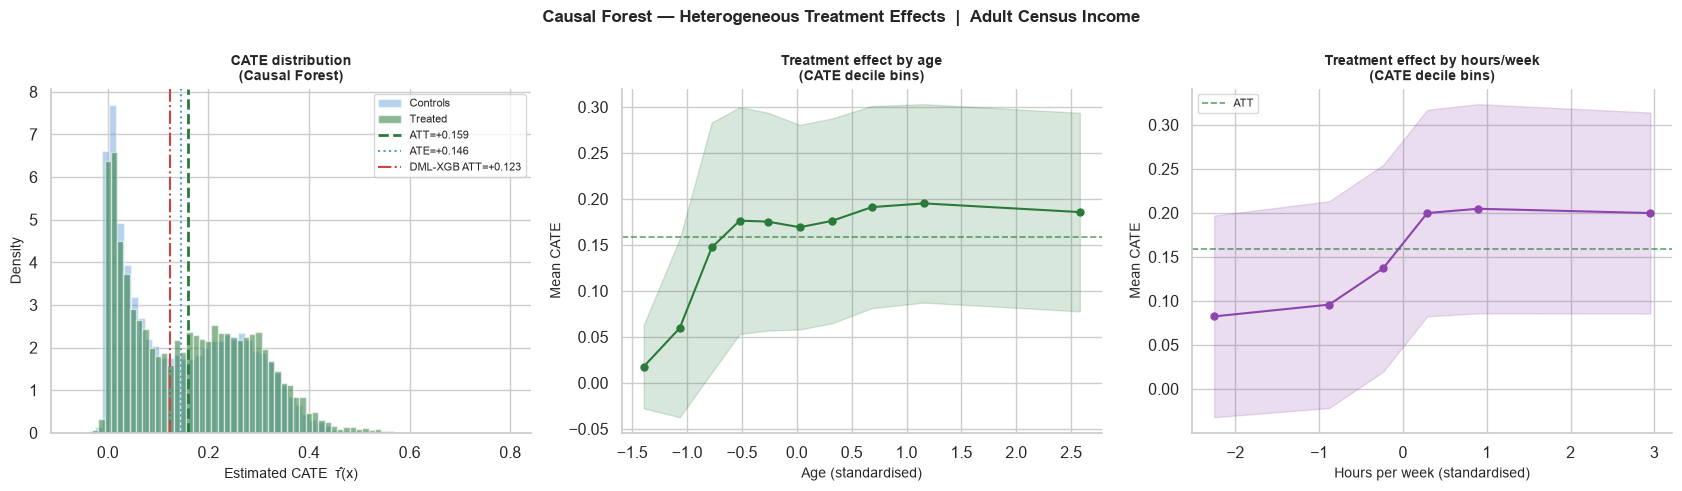

In [25]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# --- Panel A: CATE distribution ---
ax = axes[0]
ax.hist(cate_all[d_arr == 0], bins=60, density=True, alpha=0.45,
        color='#5b9bd5', label='Controls')
ax.hist(cate_treated, bins=60, density=True, alpha=0.55,
        color='#2a7a3b', label='Treated')
ax.axvline(att_cf, color='#2a7a3b', lw=2.0, ls='--',
           label=f'ATT={att_cf:+.3f}')
ax.axvline(ate_cf, color='#5b9bd5', lw=1.5, ls=':',
           label=f'ATE={ate_cf:+.3f}')
# DML-XGB ATT for reference
dml_att_ref = float(xgb_summary['coef'].iloc[0])
ax.axvline(dml_att_ref, color='#cc4444', lw=1.5, ls='-.',
           label=f'DML-XGB ATT={dml_att_ref:+.3f}')
ax.set_xlabel('Estimated CATE  τ̂(x)', fontsize=10)
ax.set_ylabel('Density', fontsize=10)
ax.set_title('CATE distribution\n(Causal Forest)', fontsize=10, fontweight='bold')
ax.legend(fontsize=8); ax.spines[['top','right']].set_visible(False)

# --- Panel B: CATE by age (binned) ---
ax = axes[1]
age_col = X_cols.index('age')
age_z   = X_arr[:, age_col]                     # standardised
# Bin into deciles
age_bins = pd.qcut(pd.Series(age_z), 10, duplicates='drop')
bin_mid  = age_bins.apply(lambda iv: iv.mid).astype(float)
cate_by_age = pd.DataFrame({'age_z': bin_mid, 'cate': cate_all}).groupby('age_z')['cate'].agg(['mean','std'])
ax.fill_between(cate_by_age.index,
                cate_by_age['mean'] - cate_by_age['std'],
                cate_by_age['mean'] + cate_by_age['std'],
                alpha=0.18, color='#2a7a3b')
ax.plot(cate_by_age.index, cate_by_age['mean'], 'o-', color='#2a7a3b', ms=5)
ax.axhline(att_cf, color='#2a7a3b', lw=1.2, ls='--', alpha=0.7)
ax.set_xlabel('Age (standardised)', fontsize=10)
ax.set_ylabel('Mean CATE', fontsize=10)
ax.set_title('Treatment effect by age\n(CATE decile bins)', fontsize=10, fontweight='bold')
ax.spines[['top','right']].set_visible(False)

# --- Panel C: CATE by hours-per-week (binned) ---
ax = axes[2]
hrs_col  = X_cols.index('hours-per-week')
hrs_z    = X_arr[:, hrs_col]
hrs_bins = pd.qcut(pd.Series(hrs_z), 10, duplicates='drop')
bin_mid2 = hrs_bins.apply(lambda iv: iv.mid).astype(float)
cate_by_hrs = pd.DataFrame({'hrs_z': bin_mid2, 'cate': cate_all}).groupby('hrs_z')['cate'].agg(['mean','std'])
ax.fill_between(cate_by_hrs.index,
                cate_by_hrs['mean'] - cate_by_hrs['std'],
                cate_by_hrs['mean'] + cate_by_hrs['std'],
                alpha=0.18, color='#8e44ad')
ax.plot(cate_by_hrs.index, cate_by_hrs['mean'], 'o-', color='#8e44ad', ms=5)
ax.axhline(att_cf, color='#2a7a3b', lw=1.2, ls='--', alpha=0.7, label='ATT')
ax.set_xlabel('Hours per week (standardised)', fontsize=10)
ax.set_ylabel('Mean CATE', fontsize=10)
ax.set_title('Treatment effect by hours/week\n(CATE decile bins)', fontsize=10, fontweight='bold')
ax.legend(fontsize=8); ax.spines[['top','right']].set_visible(False)

fig.suptitle('Causal Forest — Heterogeneous Treatment Effects  |  Adult Census Income',
             fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()

                         coef   2.5 %  97.5 %
Naive (unconditional)  0.3209  0.3112  0.3305
DML (logistic)         0.1421  0.1299  0.1542
DML (random forest)    0.1335  0.1205  0.1464
DML (xgboost)          0.1229  0.1117  0.1340
OLS / LPM              0.1606  0.1507  0.1706
Logistic AME           0.1240  0.1164  0.1334
IPW (logistic)         0.1454  0.1277  0.1631
IPW (RF)               0.2128  0.2010  0.2245
PSM (logistic)         0.1480  0.1278  0.1667
PSM (RF)               0.1043  0.1018  0.1516
Causal Forest (GRF)    0.1591  0.1579  0.1603



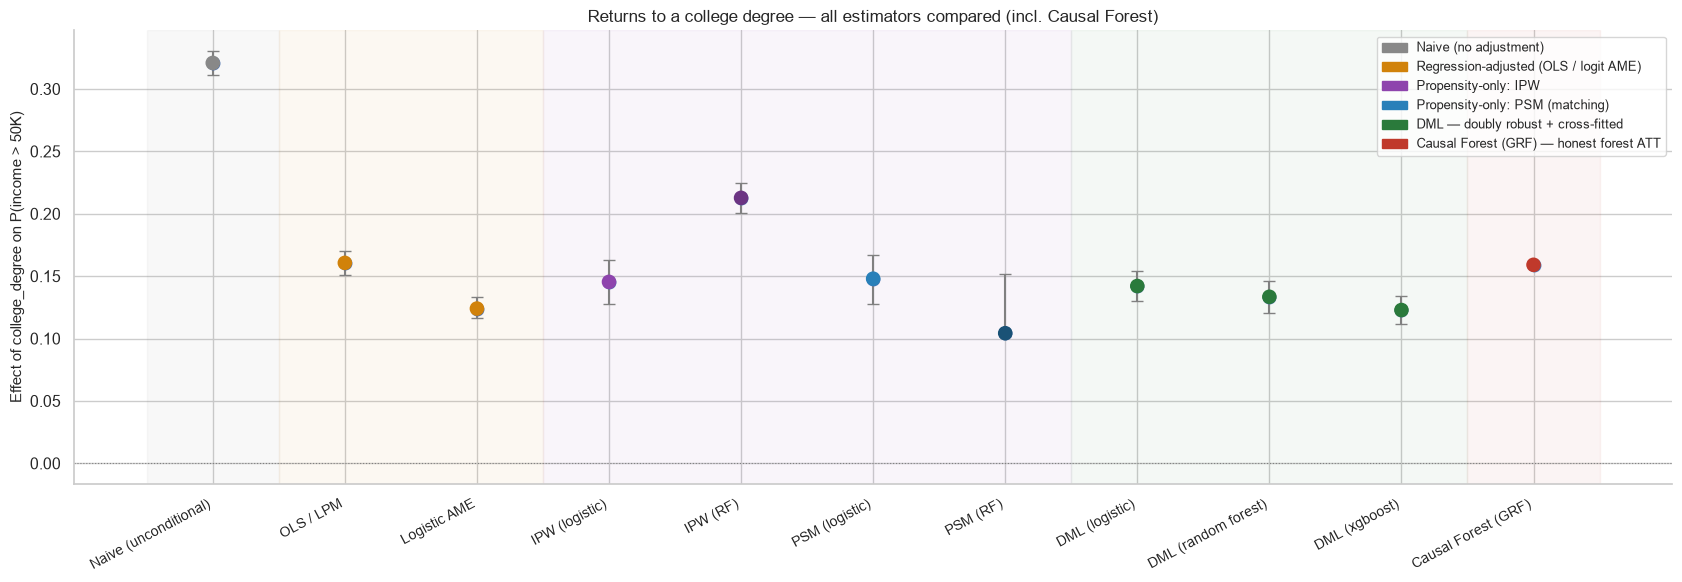

In [26]:
# Add Causal Forest ATT to the master summary table
cf_summary = _make_summary(att_cf, att_se_cf, att_lo_cf, att_hi_cf)

att_summary_full = pd.concat((
    att_summary,        # already includes naive, OLS, logit, IPW, PSM, DML
    cf_summary,
))
att_summary_full.index = list(att_summary.index) + ['Causal Forest (GRF)']

print(att_summary_full[['coef', '2.5 %', '97.5 %']].round(4).to_string())
print()

# Updated comparison forest plot with all 11 estimators
order_full = [
    'Naive (unconditional)',
    'OLS / LPM', 'Logistic AME',
    'IPW (logistic)', 'IPW (RF)',
    'PSM (logistic)', 'PSM (RF)',
    'DML (logistic)', 'DML (random forest)', 'DML (xgboost)',
    'Causal Forest (GRF)',
]
clr_full = [
    '#888888',
    '#d1820a', '#d1820a',
    '#8e44ad', '#6c3483',
    '#2980b9', '#1a5276',
    '#2a7a3b', '#2a7a3b', '#2a7a3b',
    '#c0392b',          # Causal Forest — distinct red
]

plot_df2 = att_summary_full.loc[order_full]
err2 = np.vstack([plot_df2['coef'] - plot_df2['2.5 %'],
                  plot_df2['97.5 %'] - plot_df2['coef']])

fig, ax = plt.subplots(figsize=(17, 6))
ax.errorbar(range(len(plot_df2)), plot_df2['coef'], yerr=err2,
            fmt='o', ecolor='grey', capsize=4, markersize=9, linestyle='none')
ax.scatter(range(len(plot_df2)), plot_df2['coef'], c=clr_full, s=90, zorder=3)
ax.axhline(0, color='grey', lw=0.8, ls=':')
ax.axvspan(-0.5,  0.5, alpha=0.05, color='grey')
ax.axvspan( 0.5,  2.5, alpha=0.05, color='#d1820a')
ax.axvspan( 2.5,  6.5, alpha=0.05, color='#8e44ad')
ax.axvspan( 6.5,  9.5, alpha=0.05, color='#2a7a3b')
ax.axvspan( 9.5, 10.5, alpha=0.05, color='#c0392b')
ax.set_xticks(range(len(plot_df2)))
ax.set_xticklabels(plot_df2.index, rotation=28, ha='right', fontsize=10)
ax.set_ylabel('Effect of college_degree on P(income > 50K)', fontsize=11)
ax.set_title('Returns to a college degree — all estimators compared (incl. Causal Forest)',
             fontsize=12)
ax.spines[['top', 'right']].set_visible(False)
ax.legend(handles=[
    mpatches.Patch(color='#888888', label='Naive (no adjustment)'),
    mpatches.Patch(color='#d1820a', label='Regression-adjusted (OLS / logit AME)'),
    mpatches.Patch(color='#8e44ad', label='Propensity-only: IPW'),
    mpatches.Patch(color='#2980b9', label='Propensity-only: PSM (matching)'),
    mpatches.Patch(color='#2a7a3b', label='DML — doubly robust + cross-fitted'),
    mpatches.Patch(color='#c0392b', label='Causal Forest (GRF) — honest forest ATT'),
], loc='upper right', fontsize=9)
fig.tight_layout(); plt.show()

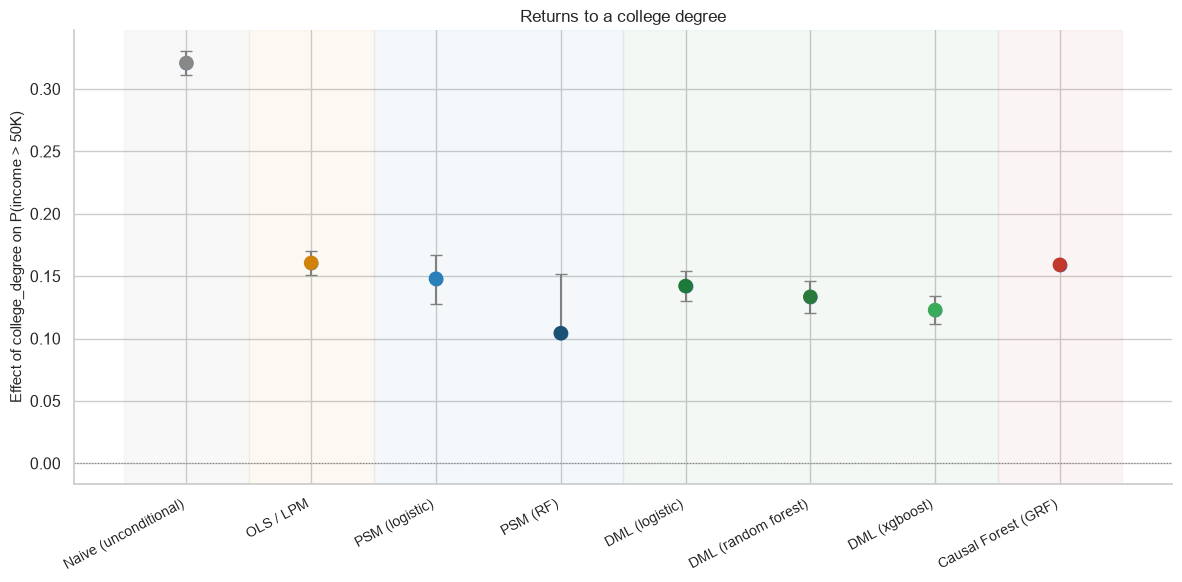

In [27]:
# ── Minimal comparison: 7 estimators that tell the cleanest story ──────────
order_min = [
    'Naive (unconditional)',
    'OLS / LPM',
    'PSM (logistic)',
    'PSM (RF)',
    'DML (logistic)',
    'DML (random forest)',
    'DML (xgboost)',
    'Causal Forest (GRF)',
]

clr_min = [
    '#888888',   # Naive
    '#d1820a',   # OLS
    '#2980b9',   # PSM logistic
    '#1a5276',   # PSM RF
    '#1e7a3b',   # DML logistic
    '#2a7a3b',   # DML RF
    '#3aaa5b',   # DML XGBoost  ← lightest green so the three DML dots are distinguishable
    '#c0392b',   # Causal Forest
]

plot_df_min = att_summary_full.loc[order_min]
err_min = np.vstack([
    plot_df_min['coef'] - plot_df_min['2.5 %'],
    plot_df_min['97.5 %'] - plot_df_min['coef'],
])

fig, ax = plt.subplots(figsize=(12, 6))

ax.errorbar(
    range(len(plot_df_min)), plot_df_min['coef'], yerr=err_min,
    fmt='o', ecolor='grey', capsize=4, markersize=9, linestyle='none',
)
ax.scatter(
    range(len(plot_df_min)), plot_df_min['coef'],
    c=clr_min, s=90, zorder=3,
)

# background shading — one band per method family
ax.axvspan(-0.5, 0.5, alpha=0.05, color='#888888')   # Naive
ax.axvspan( 0.5, 1.5, alpha=0.05, color='#d1820a')   # OLS
ax.axvspan( 1.5, 3.5, alpha=0.05, color='#2980b9')   # PSM
ax.axvspan( 3.5, 6.5, alpha=0.05, color='#2a7a3b')   # DML
ax.axvspan( 6.5, 7.5, alpha=0.05, color='#c0392b')   # Causal Forest

ax.axhline(0, color='grey', lw=0.8, ls=':')

ax.set_xticks(range(len(plot_df_min)))
ax.set_xticklabels(plot_df_min.index, rotation=28, ha='right', fontsize=10)
ax.set_ylabel('Effect of college_degree on P(income > 50K)', fontsize=11)
ax.set_title(
    'Returns to a college degree',
    fontsize=12,
)
ax.spines[['top', 'right']].set_visible(False)


fig.tight_layout()
plt.show()

n=48,842  p=52

Computing alpha (theta_0, full data 5-fold PLR) ...
  alpha = 0.1658   (27s)

Running 500 reps — non-orthogonal score, 50/50 split ...
Replication 500/500
Done in 16.8 min


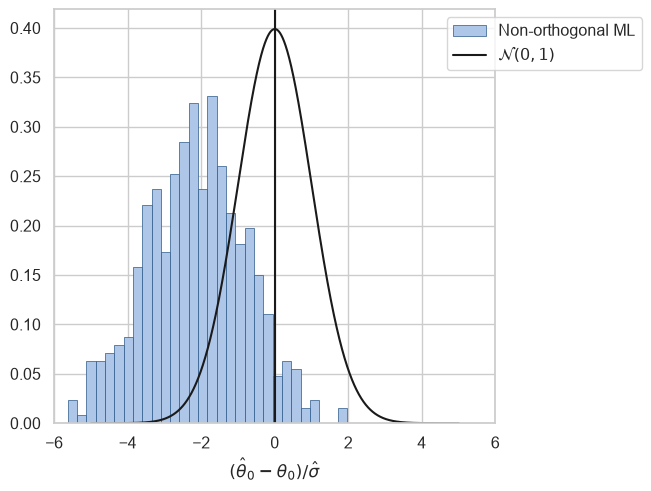

In [28]:
# Regularization Bias in Simple ML-Approaches — DoubleML docs §1.2
# Chernozhukov et al. (2018), adapted to Adult Census Income data
#
# Documentation approach (cell [4]) reproduced on our data:
#   - For each rep: bootstrap n obs, split 50/50 into i_train / i_est
#   - Fit ml_l = E[Y|X] and ml_m = E[D|X] on i_train
#   - Compute theta_initial on i_train (partialling-out from training fits)
#   - Fit ml_g = E[Y - theta_init*D | X] on i_train
#   - Get OUT-OF-SAMPLE predictions (l_hat, m_hat, g_hat) on i_est
#   - Apply non-orthogonal score on i_est:
#       psi_a = -D^2,  psi_b = D * (Y - g_hat)
#       theta = -mean(psi_b) / mean(psi_a)
#   - Collect (theta - theta_0) / se across reps
#
# The regularization bias arises because g_hat(X) is correlated with D
# (since D and X are correlated), so errors in g_hat bias the score.
import warnings, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.model_selection import KFold
warnings.filterwarnings('ignore')

# -- Data ----------------------------------------------------------------
_cat_nb = ['workclass', 'marital-status', 'occupation', 'relationship',
           'race', 'sex', 'native_country_grp']
_num_nb = ['age', 'fnlwgt', 'capital-gain', 'capital-loss', 'hours-per-week']
_Xf_nb = df[_num_nb + _cat_nb].copy()
for c in _cat_nb:
    _Xf_nb[c] = _Xf_nb[c].replace({'?': 'Unknown', 'nan': 'Unknown'})
_Xenc_nb = pd.get_dummies(_Xf_nb, columns=_cat_nb, drop_first=True)
x_nb = _Xenc_nb.values.astype(float)
y_nb = df['income_gt50k'].values.astype(float)
d_nb = df['college_degree'].values.astype(float)
n_nb = len(y_nb)
print(f'n={n_nb:,}  p={x_nb.shape[1]}')

# -- Non-orthogonal score (mirrors documentation exactly) ----------------
# psi_a = -D^2,  psi_b = D*(Y - g_hat)  where g_hat = E[Y - theta*D | X]
def non_orth_score(y, d, g_hat):
    psi_a = -d * d
    psi_b =  d * (y - g_hat)
    return psi_a, psi_b

# -- Reference theta_0 — 5-fold DML PLR on full data --------------------
def _ref_plr(x, y, d, seed):
    kf    = KFold(n_splits=5, shuffle=True, random_state=seed)
    l_hat = np.empty(len(y)); m_hat = np.empty(len(y))
    for fi, (tr, te) in enumerate(kf.split(x)):
        s = seed + fi * 100
        l_hat[te] = (RandomForestClassifier(n_estimators=200, max_depth=8,
                      min_samples_leaf=10, random_state=s, n_jobs=-1)
                     .fit(x[tr], y[tr].astype(int)).predict_proba(x[te])[:, 1])
        m_hat[te] = np.clip(
            RandomForestClassifier(n_estimators=200, max_depth=8,
             min_samples_leaf=10, random_state=s+1, n_jobs=-1)
            .fit(x[tr], d[tr].astype(int)).predict_proba(x[te])[:, 1], 0.01, 0.99)
    D_til = d - m_hat; Y_til = y - l_hat
    theta_i = np.dot(D_til, Y_til) / np.dot(D_til, D_til)
    g_hat = np.empty(len(y))
    for fi, (tr, te) in enumerate(kf.split(x)):
        s = seed + fi * 100 + 50
        g_hat[te] = (RandomForestRegressor(n_estimators=200, max_depth=8,
                      min_samples_leaf=10, random_state=s, n_jobs=-1)
                     .fit(x[tr], y[tr] - theta_i * d[tr]).predict(x[te]))
    psi_a, psi_b = non_orth_score(y, d, g_hat)
    # Use partialling-out for reference (unbiased)
    return float(np.dot(D_til, Y_til) / np.dot(D_til, D_til))

print('\nComputing alpha (theta_0, full data 5-fold PLR) ...')
t0_nb = time.time()
alpha = _ref_plr(x_nb, y_nb, d_nb, seed=42)
print(f'  alpha = {alpha:.4f}   ({time.time()-t0_nb:.0f}s)\n')

# -- Simulation — 500 reps (mirrors documentation cell [4]) -------------
np.random.seed(1111)
n_rep = 500
theta_nonorth = np.full(n_rep, np.nan)
se_nonorth    = np.full(n_rep, np.nan)

rng_nb = np.random.default_rng(1111)
t1_nb  = time.time()
print(f'Running {n_rep} reps — non-orthogonal score, 50/50 split ...')

for i_rep in range(n_rep):
    print(f'Replication {i_rep+1}/{n_rep}', end='\r')

    # Bootstrap draw
    idx_r = rng_nb.integers(0, n_nb, size=n_nb)
    x_r, y_r, d_r = x_nb[idx_r], y_nb[idx_r], d_nb[idx_r]

    # 50/50 split: train nuisance on i_train, estimate theta on i_est
    n_half = n_nb // 2
    perm   = rng_nb.permutation(n_nb)
    i_train, i_est = perm[:n_half], perm[n_half:]

    # Fit ml_l = E[Y|X] and ml_m = E[D|X] on training sample
    seed_r = i_rep + 14000
    ml_l_r = RandomForestClassifier(n_estimators=100, max_depth=8,
                                     min_samples_leaf=10, random_state=seed_r,   n_jobs=-1)
    ml_m_r = RandomForestClassifier(n_estimators=100, max_depth=8,
                                     min_samples_leaf=10, random_state=seed_r+1, n_jobs=-1)
    ml_l_r.fit(x_r[i_train], y_r[i_train].astype(int))
    ml_m_r.fit(x_r[i_train], d_r[i_train].astype(int))

    # theta_initial: partialling-out on training in-sample predictions
    l_tr = ml_l_r.predict_proba(x_r[i_train])[:, 1]
    m_tr = np.clip(ml_m_r.predict_proba(x_r[i_train])[:, 1], 0.01, 0.99)
    D_til_tr = d_r[i_train] - m_tr
    theta_initial = (np.dot(D_til_tr, y_r[i_train] - l_tr)
                     / np.dot(D_til_tr, D_til_tr))

    # Fit ml_g = E[Y - theta_initial*D | X] on training sample
    ml_g_r = RandomForestRegressor(n_estimators=100, max_depth=8,
                                    min_samples_leaf=10, random_state=seed_r+2, n_jobs=-1)
    ml_g_r.fit(x_r[i_train], y_r[i_train] - theta_initial * d_r[i_train])

    # Out-of-sample predictions on estimation sample (i_est)
    g_hat = ml_g_r.predict(x_r[i_est])

    # Non-orthogonal score on i_est
    d_est = d_r[i_est]; y_est = y_r[i_est]
    psi_a, psi_b = non_orth_score(y_est, d_est, g_hat)
    theta  = -np.mean(psi_b) / np.mean(psi_a)
    psi_i  = psi_b + theta * psi_a
    se     = np.sqrt(np.mean(psi_i**2) / (len(i_est) * np.mean(psi_a)**2))

    theta_nonorth[i_rep] = theta
    se_nonorth[i_rep]    = se

print(f'Replication {n_rep}/{n_rep}')
print(f'Done in {(time.time()-t1_nb)/60:.1f} min')

# -- Figure (mirrors documentation style) --------------------------------
face_colors = ['#aec6e8', '#ffb3ba', '#b5e8b5']
edge_colors = ['#2a5888', '#a04020', '#2e7a5a']

fig_non_orth, ax = plt.subplots(constrained_layout=True)
t_nb = (theta_nonorth - alpha) / se_nonorth
t_nb = t_nb[np.isfinite(t_nb)]
ax.hist(t_nb, bins=30, density=True,
        color=face_colors[0], edgecolor=edge_colors[0],
        linewidth=0.5, label='Non-orthogonal ML')
ax.axvline(0., color='k')
xx = np.arange(-5, +5, 0.001)
yy = stats.norm.pdf(xx)
ax.plot(xx, yy, color='k', label=r'$\mathcal{N}(0, 1)$')
ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.0))
ax.set_xlim([-6., 6.])
ax.set_xlabel(r'$(\hat{\theta}_0 - \theta_0)/\hat{\sigma}$')
plt.savefig('non_orth.png', dpi=150, bbox_inches='tight')
plt.show()

n=48,842  p=52

Computing theta_0 (full data, 5-fold PLR, n_est=200) ...
  theta_0 = 0.1393   (37s)

Running 500 reps — orthogonal IV-type score, no sample splitting ...
  Replication 50/500 | 3.8 min | ETA 33.8 min
  Replication 100/500 | 6.9 min | ETA 27.7 min
  Replication 150/500 | 10.2 min | ETA 23.9 min
  Replication 200/500 | 13.5 min | ETA 20.2 min
  Replication 250/500 | 16.7 min | ETA 16.7 min
  Replication 300/500 | 19.9 min | ETA 13.3 min
  Replication 350/500 | 23.8 min | ETA 10.2 min
  Replication 400/500 | 27.3 min | ETA 6.8 min
  Replication 450/500 | 30.7 min | ETA 3.4 min
  Replication 500/500 | 34.2 min | ETA 0.0 min

Done in 34.2 min


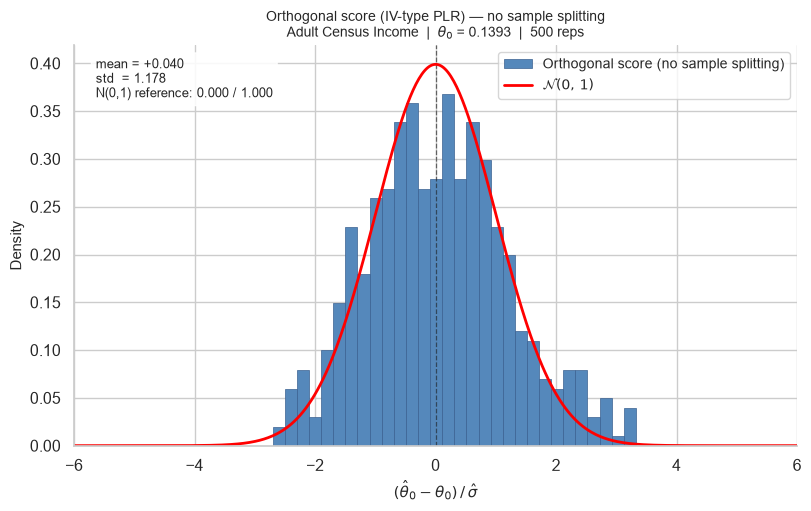


Studentised t-stats — orthogonal score, no sample splitting:
  mean = +0.040  (non-zero → overfitting bias persists despite Neyman orthogonality)
  std  = 1.178  (N(0,1) reference = 1.000)

Interpretation:
  The orthogonal IV-type score removes regularization bias,
  but the histogram is still shifted from 0 because the nuisance
  models (ml_l, ml_m, ml_g) are fitted and scored on the same data.
  Cross-fitting is needed to remove this residual overfitting bias.


In [29]:
# Orthogonal score WITHOUT sample splitting — DoubleML docs §1.3
# 'Overcoming regularization bias by orthogonalization'
#
# IV-type PLR score (Neyman-orthogonal), nuisance fitted on the FULL
# bootstrap draw, scored on those same observations (no cross-fitting).
#
# Score: psi = (Y - g_hat - theta * D) * (D - m_hat)  [IV-type PLR]
#
# Despite the orthogonal score, overfitting bias remains because
# g_hat and m_hat are evaluated on the data used to fit them.
# This is exactly the second bias addressed by cross-fitting (Fig. 2).
import warnings, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.model_selection import KFold
warnings.filterwarnings('ignore')

# -- Data ----------------------------------------------------------------
_cat_os = ['workclass', 'marital-status', 'occupation', 'relationship',
           'race', 'sex', 'native_country_grp']
_num_os = ['age', 'fnlwgt', 'capital-gain', 'capital-loss', 'hours-per-week']
_Xf_os = df[_num_os + _cat_os].copy()
for c in _cat_os:
    _Xf_os[c] = _Xf_os[c].replace({'?': 'Unknown', 'nan': 'Unknown'})
_Xenc_os = pd.get_dummies(_Xf_os, columns=_cat_os, drop_first=True)
x_os = _Xenc_os.values.astype(float)
y_os = df['income_gt50k'].values.astype(float)
d_os = df['college_degree'].values.astype(float)
n_os = len(y_os)
print(f'n={n_os:,}  p={x_os.shape[1]}')

# -- RF hyperparameters --------------------------------------------------
_kw_sim = dict(n_estimators=100, max_depth=8, min_samples_leaf=10)
_kw_ref = dict(n_estimators=200, max_depth=8, min_samples_leaf=10)

# -- Reference theta_0 (5-fold cross-fitted PLR on full data) ------------
def _plr_xfit(x, y, d, n_folds, kw, seed):
    kf    = KFold(n_splits=n_folds, shuffle=True, random_state=seed)
    l_hat = np.empty(len(y))   # E[Y|X]
    m_hat = np.empty(len(y))   # E[D|X]
    for fi, (tr, te) in enumerate(kf.split(x)):
        s = seed + fi * 100
        l_hat[te] = (RandomForestClassifier(random_state=s, n_jobs=-1, **kw)
                     .fit(x[tr], y[tr].astype(int)).predict_proba(x[te])[:, 1])
        m_hat[te] = np.clip(
            RandomForestClassifier(random_state=s+1, n_jobs=-1, **kw)
            .fit(x[tr], d[tr].astype(int)).predict_proba(x[te])[:, 1], 0.01, 0.99)
    # Initial theta (partialling-out style)
    Y_til = y - l_hat;  D_til = d - m_hat
    theta0_init = np.dot(D_til, Y_til) / np.dot(D_til, D_til)
    # Fit g(X) = E[Y - theta*D | X] with second cross-fit pass
    g_hat = np.empty(len(y))
    for fi, (tr, te) in enumerate(kf.split(x)):
        s = seed + fi * 100 + 50
        target_tr = y[tr] - theta0_init * d[tr]
        g_hat[te] = (RandomForestRegressor(random_state=s, n_jobs=-1, **kw)
                     .fit(x[tr], target_tr).predict(x[te]))
    # IV-type score
    psi_a = -np.mean((d - m_hat) * d)
    psi_b =  np.mean((d - m_hat) * (y - g_hat))
    return -psi_b / psi_a

print('\nComputing theta_0 (full data, 5-fold PLR, n_est=200) ...')
t0_os = time.time()
theta0_os = _plr_xfit(x_os, y_os, d_os, n_folds=5, kw=_kw_ref, seed=42)
print(f'  theta_0 = {theta0_os:.4f}   ({time.time()-t0_os:.0f}s)\n')

# -- Orthogonal (IV-type) estimate with NO sample splitting --------------
# Mirrors the documentation exactly:
#   1. Fit ml_l and ml_m on full sample
#   2. Get theta_initial from partialling-out residuals
#   3. Fit ml_g on y - theta_initial * d on full sample
#   4. Final estimate via IV-type score  (all on same data — no split)
def _orth_nosplit(x, y, d, kw, seed):
    ml_l = RandomForestClassifier(random_state=seed,   n_jobs=-1, **kw)
    ml_m = RandomForestClassifier(random_state=seed+1, n_jobs=-1, **kw)
    ml_l.fit(x, y.astype(int))
    ml_m.fit(x, d.astype(int))
    l_hat = ml_l.predict_proba(x)[:, 1]
    m_hat = np.clip(ml_m.predict_proba(x)[:, 1], 0.01, 0.99)
    # Initial theta (partialling-out on same full sample)
    Y_til = y - l_hat;  D_til = d - m_hat
    theta_init = np.dot(D_til, Y_til) / np.dot(D_til, D_til)
    # Fit ml_g on residual target (full sample)
    ml_g = RandomForestRegressor(random_state=seed+2, n_jobs=-1, **kw)
    ml_g.fit(x, y - theta_init * d)
    g_hat = ml_g.predict(x)
    # IV-type score: psi = (Y - g_hat - theta*D) * (D - m_hat)
    psi_a  = -np.mean((d - m_hat) * d)
    psi_b  =  np.mean((d - m_hat) * (y - g_hat))
    theta  = -psi_b / psi_a
    # Sandwich SE
    psi_i  = (y - g_hat - theta * d) * (d - m_hat)
    se     = np.sqrt(np.mean(psi_i**2) / (len(y) * psi_a**2))
    return theta, se

# -- Simulation: 500 bootstrap draws -------------------------------------
np.random.seed(2222)   # match documentation seed style
n_rep_os = 500
theta_orth_nosplit = np.full(n_rep_os, np.nan)
se_orth_nosplit    = np.full(n_rep_os, np.nan)

rng_os = np.random.default_rng(2222)
t1_os  = time.time()
print(f'Running {n_rep_os} reps — orthogonal IV-type score, no sample splitting ...')

for i_rep in range(n_rep_os):
    idx_r = rng_os.integers(0, n_os, size=n_os)
    xb, yb, db = x_os[idx_r], y_os[idx_r], d_os[idx_r]
    theta_orth_nosplit[i_rep], se_orth_nosplit[i_rep] = \
        _orth_nosplit(xb, yb, db, kw=_kw_sim, seed=i_rep + 9000)
    if (i_rep + 1) % 50 == 0:
        elapsed = time.time() - t1_os
        eta = elapsed / (i_rep + 1) * (n_rep_os - i_rep - 1)
        print(f'  Replication {i_rep+1}/{n_rep_os} | {elapsed/60:.1f} min | ETA {eta/60:.1f} min')

print(f'\nDone in {(time.time()-t1_os)/60:.1f} min')

# -- Figure — orthogonal IV-type score, no sample splitting --------------
t_stats = (theta_orth_nosplit - theta0_os) / se_orth_nosplit
t_stats = t_stats[np.isfinite(t_stats)]

fig, ax = plt.subplots(figsize=(8, 5), constrained_layout=True)

ax.hist(t_stats,
        bins=30,
        density=True,
        color='#5588bb',
        edgecolor='#3a6090',
        linewidth=0.5,
        label='Orthogonal score (no sample splitting)')

ax.axvline(0.0, color='k', linewidth=0.9, linestyle='--', alpha=0.6)

xx = np.linspace(-6, 6, 500)
ax.plot(xx, stats.norm.pdf(xx),
        color='red', linewidth=2.0,
        label=r'$\mathcal{N}(0,\,1)$')

ax.legend(loc='upper right', fontsize=10)
ax.set_xlim([-6.0, 6.0])
ax.set_xlabel(r'$(\hat{\theta}_0 - \theta_0)\,/\,\hat{\sigma}$', fontsize=11)
ax.set_ylabel('Density', fontsize=11)
ax.set_title(
    f'Orthogonal score (IV-type PLR) — no sample splitting\n'
    f'Adult Census Income  |  '
    r'$\theta_0$' + f' = {theta0_os:.4f}  |  {len(t_stats)} reps',
    fontsize=10
)
ax.spines[['top', 'right']].set_visible(False)
ax.set_facecolor('white')
fig.patch.set_facecolor('white')

ax.text(0.03, 0.97,
        f'mean = {t_stats.mean():+.3f}\n'
        f'std  = {t_stats.std():.3f}\n'
        f'N(0,1) reference: 0.000 / 1.000',
        transform=ax.transAxes, va='top', ha='left', fontsize=9,
        bbox=dict(boxstyle='round,pad=0.35', facecolor='white', alpha=0.88))

plt.savefig('orth_nosplit.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\nStudentised t-stats — orthogonal score, no sample splitting:')
print(f'  mean = {t_stats.mean():+.3f}  '
      f'(non-zero → overfitting bias persists despite Neyman orthogonality)')
print(f'  std  = {t_stats.std():.3f}  '
      f'(N(0,1) reference = 1.000)')
print(f'\nInterpretation:')
print(f'  The orthogonal IV-type score removes regularization bias,')
print(f'  but the histogram is still shifted from 0 because the nuisance')
print(f'  models (ml_l, ml_m, ml_g) are fitted and scored on the same data.')
print(f'  Cross-fitting is needed to remove this residual overfitting bias.')

n=48,842  p=52

RF spec: {'n_estimators': 50, 'max_depth': None, 'min_samples_leaf': 1}
This RF memorises training data → in-sample error ≈ 0
Cross-fitting will show a large effect here.

Using tuned IRM Forest ATTE as theta_0: 0.1335
Running 200 bootstrap reps — overfit RF (max_depth=None, min_samples_leaf=1) ...
Both panels use IDENTICAL RF — only cross-fitting differs.

  rep  20/200 | elapsed 2.8 min | ETA 25.2 min | nosplit=0.118  crossfit=0.121
  rep  40/200 | elapsed 5.7 min | ETA 22.7 min | nosplit=0.121  crossfit=0.133
  rep  60/200 | elapsed 8.4 min | ETA 19.7 min | nosplit=0.122  crossfit=0.122
  rep  80/200 | elapsed 11.3 min | ETA 16.9 min | nosplit=0.116  crossfit=0.125
  rep 100/200 | elapsed 14.3 min | ETA 14.3 min | nosplit=0.127  crossfit=0.126
  rep 120/200 | elapsed 17.4 min | ETA 11.6 min | nosplit=0.111  crossfit=0.124
  rep 140/200 | elapsed 20.1 min | ETA 8.6 min | nosplit=0.115  crossfit=0.123
  rep 160/200 | elapsed 23.0 min | ETA 5.7 min | nosplit=0.113  cros

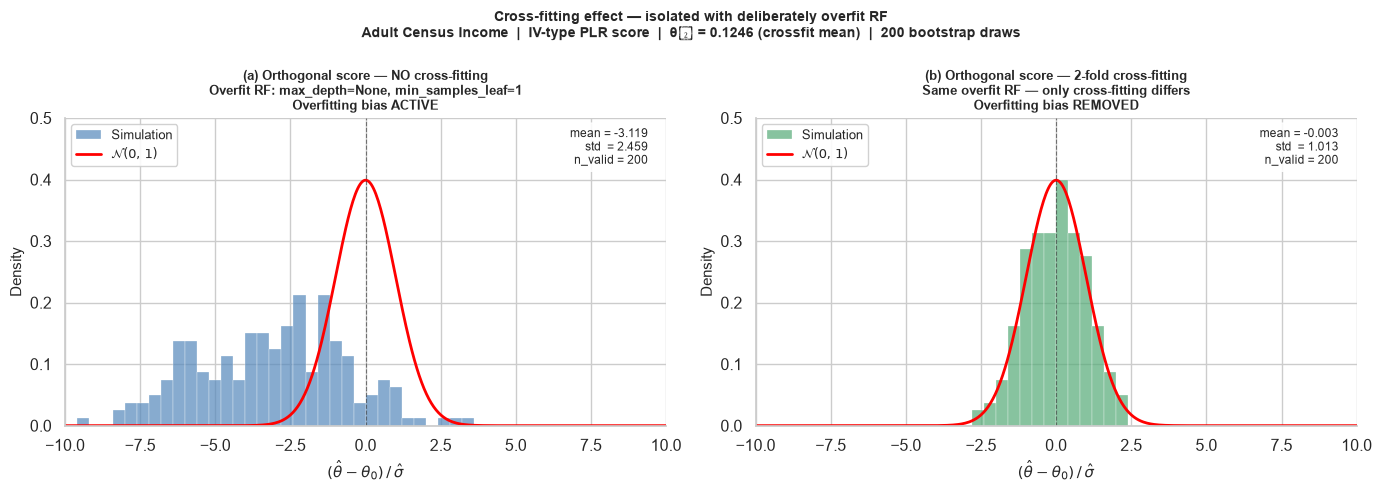


Studentized t-stat                     mean      std
──────────────────────────────────────────────────────────────
  (a) No cross-fitting (overfit RF)   -3.119    2.459
  (b) Cross-fitting (overfit RF)     -0.003    1.013
  N(0,1) reference                    0.000    1.000
──────────────────────────────────────────────────────────────

RF spec used: max_depth=None, min_samples_leaf=1, n_estimators=50
This RF memorises training data → severe overfitting bias without cross-fitting.
Cross-fitting breaks the in-sample dependence → bias removed.


In [30]:
# Cross-fitting effect — deliberately overfit RF
# max_depth=None, min_samples_leaf=1 → severe overfitting
# Blue:  IV-type PLR, orthogonal score, NO cross-fitting
# Green: IV-type PLR, orthogonal score, 2-fold cross-fitting
# Both use IDENTICAL overfit RF — only cross-fitting differs
import warnings, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.model_selection import KFold
warnings.filterwarnings('ignore')

# -- Data (same preprocessing as all other cells) ----------------------------
_cat_ov = ['workclass', 'marital-status', 'occupation', 'relationship',
           'race', 'sex', 'native_country_grp']
_num_ov = ['age', 'fnlwgt', 'capital-gain', 'capital-loss', 'hours-per-week']
_Xf_ov  = df[_num_ov + _cat_ov].copy()
for c in _cat_ov:
    _Xf_ov[c] = _Xf_ov[c].replace({'?': 'Unknown', 'nan': 'Unknown'})
_Xenc_ov = pd.get_dummies(_Xf_ov, columns=_cat_ov, drop_first=True)
x_ov = _Xenc_ov.values.astype(float)
y_ov = df['income_gt50k'].values.astype(float)
d_ov = df['college_degree'].values.astype(float)
n_ov = len(y_ov)
print(f"n={n_ov:,}  p={x_ov.shape[1]}")

# -- DELIBERATELY OVERFIT RF -------------------------------------------------
_KW_OVERFIT = dict(n_estimators=50, max_depth=None, min_samples_leaf=1)

print(f"\nRF spec: {_KW_OVERFIT}")
print("This RF memorises training data → in-sample error ≈ 0")
print("Cross-fitting will show a large effect here.\n")

# -- Helper ------------------------------------------------------------------
def _make_rf_clf(seed, kw):
    return RandomForestClassifier(random_state=seed, n_jobs=-1, **kw)

def _make_rf_reg(seed, kw):
    return RandomForestRegressor(random_state=seed, n_jobs=-1, **kw)


# -- Reference theta_0 -------------------------------------------------------
try:
    theta0_ov = float(dml_forest.summary['coef'].iloc[0])
    print(f"Using tuned IRM Forest ATTE as theta_0: {theta0_ov:.4f}")
except Exception:
    # Fallback: 5-fold cross-fitted PLR with regularized RF
    _kw_ref_ov = dict(n_estimators=200, max_depth=8, min_samples_leaf=10)
    kf_ref = KFold(n_splits=5, shuffle=True, random_state=42)
    l_ref  = np.empty(n_ov)
    m_ref  = np.empty(n_ov)
    for fi, (tr, te) in enumerate(kf_ref.split(x_ov)):
        s = 42 + fi * 100
        l_ref[te] = (_make_rf_clf(s,   _kw_ref_ov)
                     .fit(x_ov[tr], y_ov[tr].astype(int))
                     .predict_proba(x_ov[te])[:, 1])
        m_ref[te] = np.clip(
            _make_rf_clf(s+1, _kw_ref_ov)
            .fit(x_ov[tr], d_ov[tr].astype(int))
            .predict_proba(x_ov[te])[:, 1], 0.01, 0.99)
    D_til_ref = d_ov - m_ref
    Y_til_ref = y_ov - l_ref
    theta0_ov = float(np.dot(D_til_ref, Y_til_ref) / np.dot(D_til_ref, D_til_ref))
    print(f"Computed theta_0 (regularized RF, 5-fold PLR): {theta0_ov:.4f}")


# -- Estimator A — IV-type PLR, orthogonal score, NO cross-fitting -----------
def _orth_nosplit_overfit(x, y, d, kw, seed):
    ml_l = _make_rf_clf(seed,   kw); ml_l.fit(x, y.astype(int))
    ml_m = _make_rf_clf(seed+1, kw); ml_m.fit(x, d.astype(int))

    l_hat = ml_l.predict_proba(x)[:, 1]
    m_hat = np.clip(ml_m.predict_proba(x)[:, 1], 0.01, 0.99)

    D_til = d - m_hat;  Y_til = y - l_hat
    theta_init = np.dot(D_til, Y_til) / np.dot(D_til, D_til)

    ml_g = _make_rf_reg(seed+2, kw)
    ml_g.fit(x, y - theta_init * d)
    g_hat = ml_g.predict(x)

    psi_a = -np.mean((d - m_hat) * d)
    psi_b =  np.mean((d - m_hat) * (y - g_hat))
    theta  = -psi_b / psi_a

    psi_i = (y - g_hat - theta * d) * (d - m_hat)
    se    = np.sqrt(np.mean(psi_i**2) / (len(y) * psi_a**2))
    return theta, se


# -- Estimator B — IV-type PLR, orthogonal score, 2-fold cross-fitting -------
def _orth_crossfit_overfit(x, y, d, kw, seed):
    kf     = KFold(n_splits=2, shuffle=True, random_state=seed)
    splits = list(kf.split(x))

    l_hat = np.empty(len(y))
    m_hat = np.empty(len(y))

    for fi, (tr, te) in enumerate(splits):
        s = seed + fi * 100
        l_hat[te] = (_make_rf_clf(s, kw)
                     .fit(x[tr], y[tr].astype(int))
                     .predict_proba(x[te])[:, 1])
        m_hat[te] = np.clip(
            _make_rf_clf(s+1, kw)
            .fit(x[tr], d[tr].astype(int))
            .predict_proba(x[te])[:, 1], 0.01, 0.99)

    D_til = d - m_hat;  Y_til = y - l_hat
    theta_init = np.dot(D_til, Y_til) / np.dot(D_til, D_til)

    g_hat = np.empty(len(y))
    for fi, (tr, te) in enumerate(splits):
        s = seed + fi * 100 + 50
        g_hat[te] = (_make_rf_reg(s, kw)
                     .fit(x[tr], y[tr] - theta_init * d[tr])
                     .predict(x[te]))

    psi_a_vec = -(d - m_hat) * d
    psi_b_vec =  (d - m_hat) * (y - g_hat)
    psi_a = np.mean(psi_a_vec);  psi_b = np.mean(psi_b_vec)
    theta = -psi_b / psi_a

    psi_i = psi_b_vec + theta * psi_a_vec
    se    = np.sqrt(np.mean(psi_i**2) / (len(y) * psi_a**2))
    return theta, se


# -- Bootstrap simulation — 200 reps -----------------------------------------
N_SIMS_OV = 200
theta_nosplit  = np.full(N_SIMS_OV, np.nan)
se_nosplit     = np.full(N_SIMS_OV, np.nan)
theta_crossfit = np.full(N_SIMS_OV, np.nan)
se_crossfit    = np.full(N_SIMS_OV, np.nan)

rng_ov = np.random.default_rng(7777)
t_ov   = time.time()
print(f"Running {N_SIMS_OV} bootstrap reps — overfit RF "
      f"(max_depth=None, min_samples_leaf=1) ...")
print(f"Both panels use IDENTICAL RF — only cross-fitting differs.\n")

for b in range(N_SIMS_OV):
    idx       = rng_ov.integers(0, n_ov, size=n_ov)
    xb, yb, db = x_ov[idx], y_ov[idx], d_ov[idx]
    seed_b    = b + 20000

    theta_nosplit[b],  se_nosplit[b]  = _orth_nosplit_overfit(
        xb, yb, db, kw=_KW_OVERFIT, seed=seed_b)
    theta_crossfit[b], se_crossfit[b] = _orth_crossfit_overfit(
        xb, yb, db, kw=_KW_OVERFIT, seed=seed_b)

    if (b + 1) % 20 == 0:
        elapsed = time.time() - t_ov
        eta     = elapsed / (b + 1) * (N_SIMS_OV - b - 1)
        print(f"  rep {b+1:3d}/{N_SIMS_OV} | "
              f"elapsed {elapsed/60:.1f} min | "
              f"ETA {eta/60:.1f} min | "
              f"nosplit={theta_nosplit[b]:.3f}  "
              f"crossfit={theta_crossfit[b]:.3f}")

print(f"\nDone in {(time.time()-t_ov)/60:.1f} min")

# Use crossfit mean as theta_0
theta0_boot = float(theta_crossfit[~np.isnan(theta_crossfit)].mean())
print(f"\ntheta_0 (full-data reference): {theta0_ov:.4f}")
print(f"theta_0 (crossfit boot mean):  {theta0_boot:.4f}")

# Studentize
t_nosplit  = ((theta_nosplit  - theta0_boot)
              / np.where(se_nosplit  > 0, se_nosplit,  np.nan))
t_crossfit = ((theta_crossfit - theta0_boot)
              / np.where(se_crossfit > 0, se_crossfit, np.nan))

t_nosplit  = t_nosplit[np.isfinite(t_nosplit)]
t_crossfit = t_crossfit[np.isfinite(t_crossfit)]

# -- Figure ------------------------------------------------------------------
XLIM  = (-10, 10)
BINS  = np.linspace(-10, 10, 51)
XGRID = np.linspace(-10, 10, 500)
N01   = stats.norm.pdf(XGRID, 0, 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor('white')

_PANELS = [
    (axes[0], t_nosplit,
     "(a) Orthogonal score — NO cross-fitting\n"
     "Overfit RF: max_depth=None, min_samples_leaf=1\n"
     "Overfitting bias ACTIVE"),
    (axes[1], t_crossfit,
     "(b) Orthogonal score — 2-fold cross-fitting\n"
     "Same overfit RF — only cross-fitting differs\n"
     "Overfitting bias REMOVED"),
]

colors = ['#5588bb', '#55aa77']

for (ax, t_arr, title), col in zip(_PANELS, colors):
    ax.hist(t_arr, bins=BINS, density=True,
            color=col, alpha=0.70,
            edgecolor='white', linewidth=0.3,
            label="Simulation")

    ax.plot(XGRID, N01,
            color='red', linewidth=2.0,
            label=r"$\mathcal{N}(0,\,1)$")

    ax.axvline(0.0, color='#333', linewidth=0.8,
               linestyle='--', alpha=0.6)

    ax.set_xlim(XLIM)
    ax.set_ylim(0, 0.50)
    ax.set_title(title, fontsize=9, fontweight='bold')
    ax.set_xlabel(r"$(\hat{\theta} - \theta_0)\,/\,\hat{\sigma}$",
                  fontsize=11)
    ax.set_ylabel("Density", fontsize=11)
    ax.set_facecolor('white')
    ax.spines[['top', 'right']].set_visible(False)
    ax.legend(fontsize=9, framealpha=0.9, loc='upper left')

    ax.text(0.97, 0.97,
            f"mean = {t_arr.mean():+.3f}\n"
            f"std  = {t_arr.std():.3f}\n"
            f"n_valid = {len(t_arr)}",
            transform=ax.transAxes, va='top', ha='right', fontsize=8.5,
            bbox=dict(boxstyle='round,pad=0.35',
                      facecolor='white', alpha=0.88))

fig.suptitle(
    "Cross-fitting effect — isolated with deliberately overfit RF\n"
    "Adult Census Income  |  IV-type PLR score  |  "
    f"θ₀ = {theta0_boot:.4f} (crossfit mean)  |  {N_SIMS_OV} bootstrap draws",
    fontsize=10, fontweight='bold'
)
plt.tight_layout()
plt.savefig('crossfitting_effect_overfit_rf.png',
            dpi=150, bbox_inches='tight')
plt.show()

print(f"\n{'='*62}")
print(f"{'Studentized t-stat':<34} {'mean':>8} {'std':>8}")
print(f"{'─'*62}")
print(f"  {'(a) No cross-fitting (overfit RF)':<32} "
      f"{t_nosplit.mean():>+8.3f} {t_nosplit.std():>8.3f}")
print(f"  {'(b) Cross-fitting (overfit RF)':<32} "
      f"{t_crossfit.mean():>+8.3f} {t_crossfit.std():>8.3f}")
print(f"  {'N(0,1) reference':<32} {'0.000':>8} {'1.000':>8}")
print(f"{'─'*62}")
print(f"\nRF spec used: max_depth=None, min_samples_leaf=1, n_estimators=50")
print(f"This RF memorises training data → severe overfitting bias without "
      f"cross-fitting.")
print(f"Cross-fitting breaks the in-sample dependence → bias removed.")